Name: OU YANG YU

Submission Date: 25 September 2025

In [1]:
# === Core Libraries ===
from IPython.display import display        # Pretty display for DataFrames in notebooks
import numpy as np, pandas as pd           # Numerical & tabular data handling
import os, json, math, time, random, hashlib  # Utility modules: system, formats, math, timing, RNG, hashing
import matplotlib.pyplot as plt            # Visualization library

from collections import defaultdict        # Dictionary with default factory
from typing import Dict, Any, Tuple        # Type hints
from pathlib import Path                   # Object-oriented file paths

# === Scikit-learn (data prep & metrics) ===
from sklearn.model_selection import train_test_split     # Split dataset into train/val/test
from sklearn.feature_selection import VarianceThreshold  # Drop low-variance (constant) features
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,  # AUC/PR metrics
    accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, # Classification metrics
    confusion_matrix, ConfusionMatrixDisplay, brier_score_loss                   # Confusion matrix & calibration
)
from sklearn.calibration import calibration_curve        # Reliability diagrams / calibration plots

# === PyTorch (deep learning) ===
import torch
import torch.nn as nn                                    # Neural network layers & loss functions
from torch.utils.data import TensorDataset, DataLoader   # Dataset wrapper & batch loader


## Audit Dataset

In [3]:
# ===== User settings =====

# --- File & training config ---
DATA_PATH   = "IMDB Movies.csv"          # Input dataset file
HAS_HEADER  = True                       # Whether CSV has a header row
CHUNKSIZE   = 1000                       # CSV load chunk size (rows at a time)
TOPK        = 20                         # Top features (or items) to display in summaries
BATCH_SIZE  = 128                        # Batch size for DataLoader
NUM_WORKERS = 0                          # Parallel workers for DataLoader
USE_AMP     = False                      # Enable mixed precision (Automatic Mixed Precision)
USE_CUDA    = torch.cuda.is_available()  # Check if GPU (CUDA) is available
DEVICE      = "cuda" if USE_CUDA else "cpu"  # Set compute device

# --- Console banners ---
def banner(title: str):
    """Prints a formatted section title with === lines."""
    line = "=" * 12
    print(f"\n{line} {title} {line}")

# --- Format percentages nicely ---
def pct(x):
    """Convert a number into a percentage string with 2 decimals."""
    return f"{100*x:.2f}%"

# --- Ensure output folders exist ---
os.makedirs("prepared", exist_ok=True)
os.makedirs("prepared/tuning", exist_ok=True)

# --- Reproducibility setup ---
SEED = 42
random.seed(SEED)                  # Python random
np.random.seed(SEED)               # NumPy random
torch.manual_seed(SEED)            # PyTorch random
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"   # CUDA deterministic config
torch.use_deterministic_algorithms(True)            # Enforce deterministic ops
torch.backends.cudnn.deterministic = True           # Deterministic cuDNN
torch.backends.cudnn.benchmark = False              # Disable autotuner for reproducibility

# --- Safe model checkpoint loader ---
def load_state_dict_safe(path: str, map_location="cpu"):
    """
    Safely load a PyTorch checkpoint (state_dict only).
    - Uses weights_only=True (PyTorch ≥ 2.4) to suppress warnings & improve safety.
    - Falls back to normal torch.load for older versions.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


In [4]:
# ===== AUDIT (streaming, low-memory) =====
# Purpose: sanity-check the CSV file, check class balance & sparsity,
# detect duplicates, and list the most-used non-constant features.

def _describe_array(a: np.ndarray):
    """Compute summary stats (min, quantiles, mean, std) for an array."""
    if a.size == 0:
        return {}
    q = np.quantile(a, [0.00, 0.25, 0.50, 0.75, 0.90, 1.00])
    return {
        "min": int(q[0]),
        "q25": float(q[1]),
        "median": float(q[2]),
        "q75": float(q[3]),
        "q90": float(q[4]),
        "max": int(q[5]),
        "mean": float(a.mean()),
        "std": float(a.std(ddof=1)) if a.size > 1 else 0.0,
    }

def _hash_row_uint8(arr: np.ndarray) -> str:
    """Fast stable hash of a row (features+label) for duplicate detection."""
    return hashlib.md5(arr.tobytes()).hexdigest()

# --- Peek at first few rows to infer schema
_sample   = pd.read_csv(DATA_PATH, header=0 if HAS_HEADER else None, nrows=5)
_n_cols   = _sample.shape[1]
assert _n_cols >= 2, f"Expected at least 2 columns (features + label). Found: {_n_cols}."
_n_features = _n_cols - 1        # Last column = label
_label_col  = _n_cols - 1

# --- Accumulators (for stats across chunks)
n_rows = 0
class_counts = np.zeros(2, dtype=np.int64)           # [neg, pos] counts
feature_counts = np.zeros(_n_features, dtype=np.int64)  # #times each feature=1
non_binary_feat_count = 0                            # Track bad feature values
invalid_label_count   = 0                            # Track bad label values
row_ones_all, row_labels_all = [], []                # For sparsity stats
seen_hashes = set()                                  # Track row hashes
duplicate_rows = 0

# --- Chunked CSV reader (low memory)
_dtype = {i: "uint8" for i in range(_n_cols)}  # force 0/1 to uint8
_usecols = list(range(_n_cols))
_reader = pd.read_csv(
    DATA_PATH,
    header=0 if HAS_HEADER else None,
    chunksize=CHUNKSIZE,
    usecols=_usecols,
    dtype=_dtype,
)

# --- Process each chunk
for _chunk in _reader:
    X = _chunk.iloc[:, :_n_features].to_numpy(copy=False)   # features
    y = _chunk.iloc[:, _label_col].to_numpy(copy=False)     # labels

    # 1. Feature domain check (should be only 0/1)
    Xi = X if np.issubdtype(X.dtype, np.integer) else X.astype(np.int16, copy=False)
    non_binary_feat_count += int(((Xi != 0) & (Xi != 1)).sum())

    # 2. Label domain check (should be only 0/1)
    invalid_label_count   += int(((y != 0) & (y != 1)).sum())

    # 3. Class counts
    class_counts[0] += int((y == 0).sum())
    class_counts[1] += int((y == 1).sum())

    # 4. Per-row active features (for sparsity)
    ones = Xi.sum(axis=1).astype(np.int32)
    row_ones_all.append(ones)
    row_labels_all.append(y.astype(np.int8, copy=False))

    # 5. Per-feature usage (#rows where feature=1)
    feature_counts += Xi.sum(axis=0).astype(np.int64)

    # 6. Duplicate row detection (hash features+label)
    full = np.hstack([Xi, y.reshape(-1, 1).astype(np.uint8)])
    view_u8 = full.view(np.uint8)
    for i in range(view_u8.shape[0]):
        h = _hash_row_uint8(view_u8[i])
        if h in seen_hashes:
            duplicate_rows += 1
        else:
            seen_hashes.add(h)

    n_rows += X.shape[0]

# --- Combine all row-level arrays
row_ones_all   = np.concatenate(row_ones_all, axis=0) if row_ones_all else np.array([], dtype=np.int32)
row_labels_all = np.concatenate(row_labels_all, axis=0) if row_labels_all else np.array([], dtype=np.int8)

# --- Basic label stats
if n_rows == 0:
    raise RuntimeError("No rows read. Check DATA_PATH/HAS_HEADER.")
total = int(class_counts.sum())
pos_rate = class_counts[1] / max(1, total)
neg_rate = class_counts[0] / max(1, total)

# --- Sparsity summaries (overall and by class)
overall = _describe_array(row_ones_all)
by0 = _describe_array(row_ones_all[row_labels_all == 0])
by1 = _describe_array(row_ones_all[row_labels_all == 1])

# --- Constant features (all-zero or all-one)
const_zero_mask = (feature_counts == 0)
const_one_mask  = (feature_counts == n_rows)
non_const_mask  = ~(const_zero_mask | const_one_mask)

num_const_zero  = int(const_zero_mask.sum())
num_const_one   = int(const_one_mask.sum())
num_const_total = num_const_zero + num_const_one

# --- Top-K most-used non-constant features
nonconst_idx = np.where(non_const_mask)[0]
if nonconst_idx.size:
    order = np.argsort(feature_counts[nonconst_idx])[::-1]
    top_idx = nonconst_idx[order][:TOPK]
    top_feats = [(int(i), int(feature_counts[i])) for i in top_idx]
else:
    top_feats = []

# ---------- Human-readable report ----------
print("\n========== IMDB DATASET AUDIT ==========")
print(f"File: {DATA_PATH}")
print(f"Detected shape: rows={n_rows:,} | features={_n_features:,} | total_cols={_n_cols} (last column = label)")

# Binary integrity checks
print("\nBinary integrity:")
print(f"  Features (0/1 only): {'OK' if non_binary_feat_count == 0 else f'FOUND {non_binary_feat_count:,} non-binary entries'}")
print(f"  Labels   (0/1 only): {'OK' if invalid_label_count   == 0 else f'FOUND {invalid_label_count:,} invalid labels'}")

# Label distribution
print("\nLabel distribution:")
print(f"  class_0={int(class_counts[0]):,} ({neg_rate*100:.3f}%), class_1={int(class_counts[1]):,} ({pos_rate*100:.3f}%)")

print(f"\nDuplicate full rows detected (features+label): {duplicate_rows:,}")

# Helper to print stats in neat order
def _print_stats(title, d):
    print(f"\n{title}")
    if not d:
        print("  (no data)")
        return
    order = ["min","q25","median","q75","q90","max","mean","std"]
    for k in order:
        if k in d:
            val = d[k]
            if isinstance(val, float):
                print(f"  {k:>6}: {val:.3f}")
            else:
                print(f"  {k:>6}: {val}")

# Print sparsity stats
_print_stats("Per-row active-features (overall):", overall)
_print_stats("Per-row active-features — class 0:", by0)
_print_stats("Per-row active-features — class 1:", by1)

# Feature usage summary
print("\nFeature usage:")
print(f"  Constant features (zero-variance): {num_const_total} / {_n_features} "
      f"(all-zero={num_const_zero}, all-one={num_const_one})")
print(f"  Features never used (all-zero): {num_const_zero} / {_n_features}")

if top_feats:
    print(f"  Top {min(TOPK, len(top_feats))} most-used NON-constant features (feature_id -> count_ones):")
    for fid, cnt in top_feats:
        print(f"    {fid:>5} -> {cnt}")
    print("  Note: Constant columns (all-zero/all-one) are excluded and will be removed by zero-variance filtering in Q1a.")
else:
    print("  No non-constant features to list.")

print("========================================\n")



========== IMDB DATASET AUDIT ==========
File: IMDB Movies.csv
Detected shape: rows=10,000 | features=5,000 | total_cols=5001 (last column = label)

Binary integrity:
  Features (0/1 only): OK
  Labels   (0/1 only): OK

Label distribution:
  class_0=4,981 (49.810%), class_1=5,019 (50.190%)

Duplicate full rows detected (features+label): 16

Per-row active-features (overall):
     min: 11
     q25: 81.000
  median: 104.000
     q75: 151.000
     q90: 217.000
     max: 518
    mean: 123.984
     std: 65.232

Per-row active-features — class 0:
     min: 11
     q25: 83.000
  median: 106.000
     q75: 150.000
     q90: 215.000
     max: 493
    mean: 124.878
     std: 63.905

Per-row active-features — class 1:
     min: 11
     q25: 79.000
  median: 102.000
     q75: 152.000
     q90: 218.000
     max: 518
    mean: 123.098
     std: 66.518

Feature usage:
  Constant features (zero-variance): 3 / 5000 (all-zero=2, all-one=1)
  Features never used (all-zero): 2 / 5000
  Top 20 most-used NO

## Question 1a - Data Preparation

In [12]:
# ===== Q1a: Load dataset efficiently =====
# The CSV has 5,001 columns:
#   - First 5,000 = one-hot encoded features
#   - Last column = binary sentiment label (0 = negative, 1 = positive)

# Use compact dtype (uint8) since values are only 0/1 → saves memory
_pt_dtype_map = {i: "uint8" for i in range(_n_cols)}

# Load entire dataset with specified schema
# - header=0 if file has column names, else None
# - dtype map ensures each column is stored efficiently
_pt_df = pd.read_csv(DATA_PATH, header=0 if HAS_HEADER else None, dtype=_pt_dtype_map)


In [13]:
# ===== Q1a: Basic data validation & sanity checks =====
# IMDB features are one-hot encoded → must be {0,1}
# Labels are binary sentiment → must also be {0,1}

# --- Check for missing values ---
if _pt_df.isnull().values.any():
    raise ValueError("Found NaNs in the dataset")

# --- Split into features (X) and labels (y) ---
_pt_X = _pt_df.iloc[:, :_n_features].to_numpy(copy=False)   # first 5000 cols
_pt_y = _pt_df.iloc[:, _label_col].to_numpy(copy=False)     # last col

# --- Feature domain check ---
# Ensure all feature entries are strictly 0 or 1
if ((_pt_X != 0) & (_pt_X != 1)).sum() != 0:
    raise ValueError("Non-binary entries in features detected")

# --- Label domain check ---
# Ensure all labels are 0 or 1 (no unexpected values)
if not set(np.unique(_pt_y)).issubset({0,1}):
    raise ValueError(f"Unexpected label values: {np.unique(_pt_y)}")


In [14]:
# ===== Q1a: De-duplication (remove exact duplicate rows) =====
# Purpose:
# - Duplicate rows (same features + label) can bias training/evaluation
# - Removing them ensures fair performance measurement

# --- Drop duplicates across full row (all features + label) ---
_before = len(_pt_df)              # row count before
_pt_df = _pt_df.drop_duplicates()  # remove exact duplicate rows
_after = len(_pt_df)               # row count after

# --- Report how many rows were removed ---
DUP_REMOVED = _before - _after
print(f"[De-dup] Removed {DUP_REMOVED:,} duplicate rows")

# --- Re-extract features (X) and labels (y) after cleaning ---
_pt_X = _pt_df.iloc[:, :_n_features].to_numpy(copy=False)   # features
_pt_y = _pt_df.iloc[:, _label_col].to_numpy(copy=False)     # labels


[De-dup] Removed 16 duplicate rows


In [15]:
# ===== Q1a: Remove zero-variance features =====
# Purpose:
# - Drop columns that are constant (all 0s or all 1s)
# - Such features provide no useful signal
# - Removal reduces dimensionality → faster training, no info loss

# --- Apply variance threshold filter ---
_vt = VarianceThreshold(threshold=0.0)    # remove features with zero variance
_pt_X_red = _vt.fit_transform(_pt_X)      # reduced feature matrix
_kept_mask = _vt.get_support()            # boolean mask of kept features

# --- Count & report removed features ---
ZERO_VAR_REMOVED = int((~_kept_mask).sum())
FINAL_FEATURE_DIM = int(_pt_X_red.shape[1])

print(f"[VarianceThreshold] Removed {ZERO_VAR_REMOVED:,} constant features; new dim: {FINAL_FEATURE_DIM:,}")


[VarianceThreshold] Removed 3 constant features; new dim: 4,997


In [16]:
# ===== Q1a:  Train / Validation / Test Split =====
# Purpose:
# - Create separate datasets to avoid information leakage
# - Train: model learns weights
# - Val: tune hyperparameters and thresholds
# - Test: final unbiased evaluation
# - Stratification ensures ~50/50 class balance is preserved

# --- Step 1: Split train vs. temp (val+test combined) ---
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    _pt_X_red, _pt_y,
    test_size=0.30,              # hold out 30% for val+test
    stratify=_pt_y,              # preserve class distribution
    random_state=SEED            # reproducibility
)

# --- Step 2: Split temp into val vs. test ---
# 50/50 split of temp → 15% val, 15% test overall
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,              # half goes to test
    stratify=y_temp,             # preserve class balance again
    random_state=SEED
)

# --- Report final split sizes and balance ---
print(f"[Split] train={X_train.shape[0]}, val={X_val.shape[0]}, test={X_test.shape[0]}")
print(f"[Balance] pos_rate -> train={y_train.mean():.3f}, val={y_val.mean():.3f}, test={y_test.mean():.3f}")


[Split] train=6988, val=1498, test=1498
[Balance] pos_rate -> train=0.502, val=0.502, test=0.502


In [17]:
# ===== Q1a: Final input formatting for deep learning =====
# Purpose:
# - Most DL frameworks (incl. PyTorch) expect float32 inputs
# - Labels should be integers (int64) for classification
# - Since features are one-hot, no normalization/scaling is needed

def _to_tensor_pair(Xn, yn):
    """Convert NumPy arrays to PyTorch tensors (X=float32, y=int64)."""
    X_tensor = torch.from_numpy(Xn.astype(np.float32, copy=False))  # features → float32
    y_tensor = torch.from_numpy(yn.astype(np.int64, copy=False))    # labels   → int64
    return X_tensor, y_tensor

# --- Convert all splits to tensors ---
X_train_t, y_train_t = _to_tensor_pair(X_train, y_train)
X_val_t,   y_val_t   = _to_tensor_pair(X_val,   y_val)
X_test_t,  y_test_t  = _to_tensor_pair(X_test,  y_test)


In [18]:
# ===== Q1a: DataLoaders =====
# Purpose:
# - Wrap datasets into PyTorch DataLoaders for batching and iteration
# - Training loader uses shuffling, val/test loaders do not
# - Batch size and workers are configurable via user settings

# --- Create TensorDataset wrappers (X + y) ---
ds_train = TensorDataset(X_train_t, y_train_t)   # training set
ds_val   = TensorDataset(X_val_t,   y_val_t)     # validation set
ds_test  = TensorDataset(X_test_t,  y_test_t)    # test set

# --- Create DataLoaders (iterable batches) ---
dl_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,   # mini-batch size
    shuffle=True,            # shuffle each epoch for training
    num_workers=NUM_WORKERS, # parallel workers for data loading
    pin_memory=False         # keep False (CPU tensors only here)
)
dl_val = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE,
    shuffle=False,           # no shuffle → reproducible eval
    num_workers=NUM_WORKERS,
    pin_memory=False
)
dl_test = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,           # test set must be fixed order
    num_workers=NUM_WORKERS,
    pin_memory=False
)


In [20]:
# ===== Q1a: Class Weights (for imbalanced data handling) =====
# Purpose:
# - If dataset is imbalanced, apply class weights in loss functions
# - Helps the model not bias toward the majority class
# - CE weights → for CrossEntropyLoss
# - pos_weight → for BCEWithLogitsLoss

# --- Count positives and negatives in the training set ---
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

if n_pos and n_neg:
    # CrossEntropy: weight inversely proportional to class frequency
    ce_weights = torch.tensor(
        [(n_pos + n_neg) / (2.0 * n_neg),    # weight for class 0
         (n_pos + n_neg) / (2.0 * n_pos)],   # weight for class 1
        dtype=torch.float32
    )

    # BCE: use pos_weight (scales positive class in loss)
    bce_pos_weight = torch.tensor(
        [n_neg / n_pos], dtype=torch.float32
    )
else:
    # In case of degenerate data (all 0s or all 1s)
    ce_weights = None
    bce_pos_weight = None

# --- Print chosen weights ---
print(f"[Weights] CE: {ce_weights} | BCE pos_weight: {bce_pos_weight}")


[Weights] CE: tensor([1.0040, 0.9960]) | BCE pos_weight: tensor([0.9920])


In [21]:
# ===== Q1a: Persist processed artifacts for reproducibility =====
# Purpose:
# - Save processed datasets and metadata so results can be exactly replicated
# - Prevents need to re-run preprocessing every time
# - Ensures experiments are consistent across runs

# --- Save splits and metadata as a single .pt file ---
# Includes: train/val/test tensors, kept-feature mask, random seed, batch size
torch.save({
    "X_train":   X_train_t, "y_train": y_train_t,   # training tensors
    "X_val":     X_val_t,   "y_val":   y_val_t,     # validation tensors
    "X_test":    X_test_t,  "y_test":  y_test_t,    # test tensors
    "kept_mask": torch.from_numpy(_kept_mask.astype(np.uint8)),  # features kept after variance filter
    "seed":      SEED,                              # reproducibility seed
    "batch_size": BATCH_SIZE                        # training batch size
}, "prepared/imdb_pytorch_splits.pt")

# --- Confirm completion ---
print("[Done] dl_train/dl_val/dl_test ready; artifacts saved to prepared/imdb_pytorch_splits.pt")


[Done] dl_train/dl_val/dl_test ready; artifacts saved to prepared/imdb_pytorch_splits.pt


In [22]:
# === Q1a: Data Preparation Summary (human readable) ===
banner("Q1a: Data Preparation Summary")

# --- 1) Headline stats ---
# Show dataset shape and preprocessing steps applied
print(f"Original shape: rows={n_rows:,} | features={_n_features:,}")
print(f"After de-dup: removed {DUP_REMOVED:,} duplicate rows")
print(f"Zero-variance features removed (all 0 or all 1): {ZERO_VAR_REMOVED:,}")
print(f"Final feature dimension: {FINAL_FEATURE_DIM:,}")

# --- 2) Split sizes and balances ---
# Record number of rows in each split
split_rows = {
    "train": len(y_train),
    "val":   len(y_val),
    "test":  len(y_test),
}

def split_stats(name, y):
    """Return row counts and class balance for a split."""
    y = np.asarray(y)
    n = len(y)
    pos = int((y == 1).sum())
    neg = n - pos
    return {"rows": n, "pos": pos, "neg": neg, "pos_rate": pos / (n + 1e-12)}

# Collect stats for all splits
stats = {
    "train": split_stats("train", y_train),
    "val":   split_stats("val", y_val),
    "test":  split_stats("test", y_test),
}

# Build summary table with class balance (% positives)
tbl = pd.DataFrame(stats).T[["rows", "pos", "neg", "pos_rate"]]
tbl["pos_rate"] = tbl["pos_rate"].map(lambda x: f"{100*x:.2f}%")

# Display split summary in a neat table
banner("Split Summary (stratified 70/15/15)")
display(tbl)

# --- 3) Dtype confirmation (DL readiness check) ---
# Confirm that tensors are in the right format for PyTorch
banner("DL Readiness Check")
print(f"X_train dtype: {X_train_t.dtype} | y_train dtype: {y_train_t.dtype}")
print(f"DataLoaders: train={split_rows['train']:,} rows | val={split_rows['val']:,} | test={split_rows['test']:,}")

# --- 4) Saved artifacts ---
# Remind user that artifacts were persisted for reproducibility
banner("Saved Artifacts")
print("prepared/imdb_pytorch_splits.pt  (tensors + kept_mask + seed + batch_size)")



============ Q1a: Data Preparation Summary ============
Original shape: rows=10,000 | features=5,000
After de-dup: removed 16 duplicate rows
Zero-variance features removed (all 0 or all 1): 3
Final feature dimension: 4,997

============ Split Summary (stratified 70/15/15) ============


,rows,pos,neg,pos_rate
train,6988.0,3508.0,3480.0,50.20%
val,1498.0,752.0,746.0,50.20%
test,1498.0,752.0,746.0,50.20%



============ DL Readiness Check ============
X_train dtype: torch.float32 | y_train dtype: torch.int64
DataLoaders: train=6,988 rows | val=1,498 | test=1,498

============ Saved Artifacts ============
prepared/imdb_pytorch_splits.pt  (tensors + kept_mask + seed + batch_size)


## Question 1b - Design & Train a Deep Model for Sentiment Classification

In [23]:
# --- Q1b: Reuse dataloaders from Q1a if available; else load from saved tensors ---
def _ensure_dataloaders():
    """
    Ensures dataloaders (train/val/test) are available.
    - If already created in Q1a, reuse them
    - Otherwise, reload from saved artifacts in prepared/imdb_pytorch_splits.pt
    """

    # Check if dataloaders already exist in the global namespace
    global dl_train, dl_val, dl_test, X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, _kept_mask
    has = all(name in globals() for name in ["dl_train", "dl_val", "dl_test"])
    if has:
        return  # Already defined, nothing to do

    # --- Load pre-saved tensors & metadata ---
    ckpt = load_state_dict_safe("prepared/imdb_pytorch_splits.pt", map_location="cpu")
    X_train_t, y_train_t = ckpt["X_train"], ckpt["y_train"]
    X_val_t,   y_val_t   = ckpt["X_val"],   ckpt["y_val"]
    X_test_t,  y_test_t  = ckpt["X_test"],  ckpt["y_test"]
    _kept_mask           = ckpt["kept_mask"]          # feature selection mask
    BATCH_SIZE           = int(ckpt.get("batch_size", 128))  # default to 128 if missing

    # --- Wrap tensors back into TensorDatasets ---
    ds_train = TensorDataset(X_train_t, y_train_t)
    ds_val   = TensorDataset(X_val_t,   y_val_t)
    ds_test  = TensorDataset(X_test_t,  y_test_t)

    # --- Recreate DataLoaders ---
    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# Call to ensure dataloaders are available
_ensure_dataloaders()

# --- Final sanity check ---
in_dim = X_train_t.shape[1]
assert in_dim > 0, "Input dimension must be > 0"   # Ensure dataset is non-empty


In [24]:
# --- Q1b: Model: Wide & Deep MLP ---
# Combines:
# - Wide path: linear model (memorization of simple patterns)
# - Deep path: multi-layer perceptron (generalization from complex interactions)
# Final output = sum of wide(x) + deep(x)

class WideDeepMLP(nn.Module):
    def __init__(self, in_features: int, p_drop: float = 0.30):
        super().__init__()

        # --- Wide path (linear) ---
        self.wide = nn.Linear(in_features, 1, bias=True)

        # --- Deep path (non-linear) ---
        self.deep = nn.Sequential(
            nn.Linear(in_features, 1024),  # fully connected layer
            nn.ReLU(inplace=True),         # activation
            nn.Dropout(p_drop),            # dropout for regularization
            nn.Linear(1024, 256),          # hidden layer
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 1),             # output logits
        )

        # --- Weight initialization ---
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")  # good for ReLU
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        Forward pass.
        Input:  x [batch_size, in_features]
        Output: logits [batch_size]
        """
        logits = self.wide(x) + self.deep(x)   # combine wide + deep
        return logits.squeeze(1)               # remove last dim → shape [B]

# --- Utility: count trainable parameters ---
def count_params(model: nn.Module) -> int:
    """Return total number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [25]:
# --- Q1b: Training / Evaluation functions ---

# Gradient scaler for mixed precision (speeds up training on GPU)
scaler = torch.amp.GradScaler(device=DEVICE, enabled=USE_AMP and USE_CUDA)

def _epoch(model, loader, train: bool, optimizer=None, criterion=None):
    """
    Runs one full epoch (train or eval).
    Args:
        model:      PyTorch model
        loader:     DataLoader (train/val/test)
        train:      True = training mode, False = eval mode
        optimizer:  optimizer (only used if train=True)
        criterion:  loss function

    Returns:
        avg_loss:   mean loss over the epoch
        acc:        accuracy at threshold 0.5
        auc:        AUROC (Area Under ROC curve)
    """
    model.train(mode=train)  # toggle train/eval mode
    losses = []
    all_probs, all_targets = [], []

    # --- Loop over mini-batches ---
    for xb, yb in loader:
        # Move data to device
        xb = xb.to(DEVICE, non_blocking=False)
        yb = yb.to(DEVICE, non_blocking=False).float()

        if train:
            # --- Training mode ---
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)           # forward pass
                loss = criterion(logits, yb) # compute loss
            scaler.scale(loss).backward()    # backprop with scaling (AMP safe)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding grads
            scaler.step(optimizer)           # update weights
            scaler.update()
        else:
            # --- Evaluation mode (no gradient updates) ---
            with torch.no_grad():
                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    logits = model(xb)
                    loss = criterion(logits, yb)

        # --- Collect metrics ---
        losses.append(loss.detach().item())
        probs = torch.sigmoid(logits).detach().float().cpu().numpy()  # convert logits → probs
        all_probs.append(probs)
        all_targets.append(yb.detach().float().cpu().numpy())

    # --- Aggregate results across batches ---
    avg_loss = float(np.mean(losses))
    y_true = np.concatenate(all_targets)  # ground-truth labels
    y_prob = np.concatenate(all_probs)    # predicted probabilities
    y_pred = (y_prob >= 0.5).astype(np.int32)  # binary predictions at 0.5 threshold

    # Accuracy
    acc = float(accuracy_score(y_true, y_pred))

    # AUROC (try/except in case all labels are same class)
    try:
        auc = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        auc = float("nan")

    return avg_loss, acc, auc


In [26]:
# ===== Q1b: Hyperparameter Tuning (objective = maximize validation AUROC) =====

# --- Search space (compact; can be expanded as needed) ---
HSPACE = {
    "p_drop":       [0.20, 0.30, 0.40],   # dropout rate
    "lr":           [5e-4, 1e-3, 2e-3],   # learning rate
    "weight_decay": [1e-5, 1e-4, 5e-4],   # L2 regularization
    "batch_size":   [64, 128, 256],       # training batch size
    # Scheduler / training meta-parameters
    "lr_factor":    [0.5, 0.6],           # LR reduction factor
    "lr_patience":  [1, 2],               # epochs to wait before reducing LR
    "min_lr":       [1e-5],               # lower LR bound
    "max_epochs":   [20],                 # max training epochs (usually early stopping kicks in)
    "patience":     [3, 4, 5],            # early stopping patience (no improvement in val AUC)
}

# --- Utility: sample random configuration ---
def _sample(space: Dict[str, list]) -> Dict[str, Any]:
    """Pick one random value per hyperparameter from the search space."""
    return {k: random.choice(v) for k, v in space.items()}

# --- Utility: build dataloaders for a given batch size ---
def _make_loaders(batch_size: int) -> Tuple[DataLoader, DataLoader]:
    """Return train/val DataLoaders with the specified batch size."""
    dl_tr = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True,  num_workers=0)
    dl_va = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=batch_size, shuffle=False, num_workers=0)
    return dl_tr, dl_va

# --- Utility: run one trial with given hyperparameters ---
def _run_trial(cfg: Dict[str, Any], trial_id: int, verbose: bool=False):
    """
    Train/evaluate one trial:
    - Build model with trial config
    - Train until early stopping
    - Return best val AUC, epoch, and weights
    """
    # --- Data ---
    dl_train, dl_val = _make_loaders(cfg["batch_size"])

    # --- Model ---
    in_dim = X_train_t.shape[1]
    model = WideDeepMLP(in_features=in_dim, p_drop=cfg["p_drop"]).to(DEVICE)

    # --- Loss (BCE with class balance) ---
    n_pos = int((y_train_t == 1).sum().item())
    n_neg = int((y_train_t == 0).sum().item())
    pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Optimizer & scheduler ---
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=cfg["lr_factor"],
        patience=cfg["lr_patience"], min_lr=cfg["min_lr"]
    )

    # --- Training loop with early stopping on val AUC ---
    history_rows = []
    best_auc, best_epoch, best_state = -1.0, -1, None
    no_improve = 0

    for epoch in range(1, cfg["max_epochs"] + 1):
        # Train & validate
        tr_loss, tr_acc, tr_auc = _epoch(model, dl_train, train=True,  optimizer=optimizer, criterion=criterion)
        va_loss, va_acc, va_auc = _epoch(model, dl_val,   train=False, optimizer=None,      criterion=criterion)
        scheduler.step(va_auc)

        # Log history
        history_rows.append({
            "trial": trial_id, "epoch": epoch,
            "train_loss": tr_loss, "train_auc": tr_auc,
            "val_loss": va_loss,   "val_auc": va_auc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if verbose:
            print(f"[T{trial_id:02d} E{epoch:02d}] tr_auc={tr_auc:.4f}  val_auc={va_auc:.4f}  lr={optimizer.param_groups[0]['lr']:.5f}")

        # Track best checkpoint
        if va_auc > best_auc + 1e-4:
            best_auc = float(va_auc)
            best_epoch = int(epoch)
            best_state = {k: v.detach().clone().cpu() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= cfg["patience"]:  # stop if no improvement
                break

    # Save trial history
    hist_df = pd.DataFrame(history_rows)
    return {
        "trial": trial_id,
        "config": cfg,
        "best_val_auc": best_auc,
        "best_epoch": best_epoch,
        "state": best_state,
        "history": hist_df,
    }

# --- Run random search across trials ---
N_TRIALS = 15  # adjust to fit compute budget
banner(f"Hyperparameter Tuning — {N_TRIALS} trials (objective: max val AUROC)")

results, all_hist = [], []
best = {"best_val_auc": -1.0}

for t in range(1, N_TRIALS + 1):
    cfg = _sample(HSPACE)                     # pick random hyperparameters
    banner(f"Trial {t}/{N_TRIALS} | cfg={cfg}")
    out = _run_trial(cfg, trial_id=t, verbose=False)

    # Collect results
    results.append({
        "trial": out["trial"],
        "best_val_auc": out["best_val_auc"],
        "best_epoch": out["best_epoch"],
        **cfg
    })
    all_hist.append(out["history"])

    # Update best model
    if out["best_val_auc"] > best["best_val_auc"]:
        best = out
        # Save best state & config immediately
        torch.save(best["state"], "prepared/tuning/model_best.pt")
        with open("prepared/tuning/best_config.json", "w") as f:
            json.dump(best["config"], f, indent=2)
        print(f"[BEST] T{t}: val_auc={best['best_val_auc']:.4f} (epoch {best['best_epoch']}) — saved")

# --- Persist results (leaderboard + all histories) ---
res_df = pd.DataFrame(results).sort_values("best_val_auc", ascending=False)
hist_all_df = pd.concat(all_hist, ignore_index=True) if all_hist else pd.DataFrame()
res_df.to_csv("prepared/tuning/tuning_results.csv", index=False)
hist_all_df.to_csv("prepared/tuning/tuning_history_all.csv", index=False)

# --- Export the BEST trial's history for downstream Q1b/Q1c ---
best_hist = best["history"].drop(columns=["trial"]).copy()
best_hist.to_csv("prepared/history_q1b.csv", index=False)

# --- Make tuned model the default for Q1c evaluation ---
state = load_state_dict_safe("prepared/tuning/model_best.pt", map_location="cpu")
torch.save(state, "prepared/model_q1b_widedeep.pt")  # Q1c expects this path

# --- Quick confirmation of saved artifacts ---
print("\nSaved:")
print("  prepared/model_q1b_widedeep.pt     (tuned best, used by Q1c)")
print("  prepared/history_q1b.csv           (best trial history for curves)")
print("  prepared/tuning/model_best.pt")
print("  prepared/tuning/best_config.json")
print("  prepared/tuning/tuning_results.csv")
print("  prepared/tuning/tuning_history_all.csv")



============ Hyperparameter Tuning — 15 trials (objective: max val AUROC) ============

============ Trial 1/15 | cfg={'p_drop': 0.4, 'lr': 0.0005, 'weight_decay': 1e-05, 'batch_size': 256, 'lr_factor': 0.6, 'lr_patience': 1, 'min_lr': 1e-05, 'max_epochs': 20, 'patience': 5} ============
[BEST] T1: val_auc=0.9394 (epoch 2) — saved

============ Trial 2/15 | cfg={'p_drop': 0.2, 'lr': 0.002, 'weight_decay': 0.0005, 'batch_size': 256, 'lr_factor': 0.5, 'lr_patience': 2, 'min_lr': 1e-05, 'max_epochs': 20, 'patience': 3} ============
[BEST] T2: val_auc=0.9442 (epoch 1) — saved

============ Trial 3/15 | cfg={'p_drop': 0.2, 'lr': 0.0005, 'weight_decay': 0.0005, 'batch_size': 256, 'lr_factor': 0.5, 'lr_patience': 1, 'min_lr': 1e-05, 'max_epochs': 20, 'patience': 4} ============

============ Trial 4/15 | cfg={'p_drop': 0.4, 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 64, 'lr_factor': 0.6, 'lr_patience': 2, 'min_lr': 1e-05, 'max_epochs': 20, 'patience': 3} ============

============ Tri

In [27]:
# === Q1b: Model & Training Summary (human-readable) ===
banner("Q1b: Model & Training Summary")

# ---- Ensure test loader is available (reuse or reload splits) ----
def _ensure_splits_and_test_loader():
    """
    Guarantee availability of X/y splits and test DataLoader.
    - If missing, reload from saved artifacts.
    - Batch size comes from tuned config if available.
    """
    need = ["X_train_t","y_train_t","X_val_t","y_val_t","X_test_t","y_test_t"]
    if not all(n in globals() for n in need):
        ck = load_state_dict_safe("prepared/imdb_pytorch_splits.pt", map_location="cpu")
        globals().update({
            "X_train_t": ck["X_train"], "y_train_t": ck["y_train"],
            "X_val_t":   ck["X_val"],   "y_val_t":   ck["y_val"],
            "X_test_t":  ck["X_test"],  "y_test_t":  ck["y_test"],
        })

    # Default batch size = 128; override if tuner saved a best config
    bs = 128
    cfg_path = "prepared/tuning/best_config.json"
    if os.path.exists(cfg_path):
        with open(cfg_path, "r") as f:
            try:
                bs = int(json.load(f).get("batch_size", 128))
            except Exception:
                pass

    # Create test DataLoader
    globals()["dl_test"] = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=bs, shuffle=False)

_ensure_splits_and_test_loader()

# ---- Paths for tuned artifacts ----
CFG_PATH   = "prepared/tuning/best_config.json"   # tuned hyperparameters
CKPT_PATH  = "prepared/model_q1b_widedeep.pt"     # tuned model weights
HIST_PATH  = "prepared/history_q1b.csv"           # training history (best trial only)
LEADERBOARD_PATH = "prepared/tuning/tuning_results.csv"  # leaderboard of trials

# ---- Load tuned config, model, history, and leaderboard ----
if not os.path.exists(CFG_PATH):   raise FileNotFoundError("Missing tuned config. Run tuning first.")
if not os.path.exists(CKPT_PATH):  raise FileNotFoundError("Missing tuned model. Run tuning first.")
if not os.path.exists(HIST_PATH):  raise FileNotFoundError("Missing history. Run tuning first.")

with open(CFG_PATH, "r") as f:
    BEST_CFG = json.load(f)

state = load_state_dict_safe(CKPT_PATH, map_location="cpu")
hist  = pd.read_csv(HIST_PATH)

if os.path.exists(LEADERBOARD_PATH):
    leaderboard = pd.read_csv(LEADERBOARD_PATH)
    n_trials = int(len(leaderboard))
    # Rank of best trial
    best_idx = leaderboard["best_val_auc"].idxmax()
    best_rank = int(leaderboard["best_val_auc"].rank(ascending=False, method="min")[best_idx])
else:
    leaderboard = None
    n_trials, best_rank = None, 1

# ---- Recreate tuned model (WideDeepMLP) ----
in_dim = X_train_t.shape[1]
model = WideDeepMLP(in_features=in_dim, p_drop=float(BEST_CFG.get("p_drop", 0.30)))
model.load_state_dict(state, strict=True)
model.to(DEVICE).eval()

# 0) Tuning overview ------------------------------------------------------------
banner("Tuning Overview")
print(f"Tuning trials executed: {n_trials if n_trials is not None else 'N/A'}")
print(f"Best trial rank: {best_rank}")
print("Best config:")
for k in ["p_drop","lr","weight_decay","batch_size","lr_factor","lr_patience","min_lr","max_epochs","patience"]:
    if k in BEST_CFG:
        v = BEST_CFG[k]
        if isinstance(v, float):
            if "lr" in k or "weight_decay" in k or k == "min_lr":
                print(f"  {k}: {v:.6f}")   # scientific-friendly formatting
            else:
                print(f"  {k}: {v:.3f}")
        else:
            print(f"  {k}: {v}")

# Show leaderboard if available
if leaderboard is not None:
    banner("Tuning Leaderboard — Top 5")
    top5 = leaderboard.sort_values("best_val_auc", ascending=False).head(5).copy()
    from IPython.display import display
    display(top5.style.format({
        "best_val_auc":"{:.6f}",
        "lr":"{:.6f}",
        "weight_decay":"{:.6f}",
        "min_lr":"{:.6f}"
    }))

# 1) Architecture ---------------------------------------------------------------
banner("Architecture")
print(model)   # model layers
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 2) Activation functions -------------------------------------------------------
banner("Activation Functions")
_act_names, _drop_ps = [], []
for m in model.modules():
    mn = type(m).__name__
    if mn in {"ReLU","LeakyReLU","GELU","Sigmoid","Tanh","SELU","ELU"} and mn not in _act_names:
        _act_names.append(mn)
    if mn == "Dropout":
        _drop_ps.append(getattr(m, "p", None))
print("In-model activations:", ", ".join(_act_names) if _act_names else "(none)")
print("Post-logit (eval): Sigmoid (applied when computing probabilities)")
if _drop_ps:
    _u = sorted({round(p, 4) for p in _drop_ps if p is not None})
    print(f"Dropout p: {', '.join(map(str, _u))}")
else:
    print("Dropout: none")

# 3) Loss function --------------------------------------------------------------
banner("Loss Function")
n_pos = int((y_train_t == 1).sum().item())
n_neg = int((y_train_t == 0).sum().item())
_posw = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=_posw.to(DEVICE))
print(type(criterion).__name__)
print(f"pos_weight: {float(_posw.numpy()[0]):.4f}")

# 4) Optimisation (report tuned hyperparams) -----------------------------------
banner("Optimisation")
print(f"Optimizer: AdamW | lr={float(BEST_CFG.get('lr', 0.0)):.6f} | weight_decay={float(BEST_CFG.get('weight_decay', 0.0)):.6f}")
print(f"Scheduler: ReduceLROnPlateau | factor={BEST_CFG.get('lr_factor')} | patience={BEST_CFG.get('lr_patience')} | min_lr={BEST_CFG.get('min_lr')}")

# 5) Hyperparameters ------------------------------------------------------------
banner("Hyperparameters")
print(f"Batch size: {BEST_CFG.get('batch_size')}")
print(f"Max epochs: {BEST_CFG.get('max_epochs')} | Early stopping patience: {BEST_CFG.get('patience')}")
print("Gradient clipping: max_norm=1.0")
print(f"Mixed precision (AMP): {'enabled on CUDA' if torch.cuda.is_available() else 'disabled (CPU)'}")
print(f"Seed: {globals().get('SEED', 42)}")

# 6) Training outcome (from best-trial history) --------------------------------
banner("Training Outcome")
best_row = hist.loc[hist["val_auc"].idxmax()]
print(f"Best epoch: {int(best_row['epoch'])}")
print(f"Validation AUC: {float(best_row['val_auc']):.4f}")

# 7) Test set performance (quick, threshold-free) -------------------------------
def _eval_quick(mdl, loader, criterion):
    """Evaluate model on a loader (loss, acc, auc) with 0.5 threshold."""
    mdl.eval()
    losses, ys, ps = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE).float()
            logits = mdl(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits).detach().float().cpu().numpy()
            losses.append(loss.detach().item())
            ys.append(yb.detach().float().cpu().numpy()); ps.append(probs)
    y_true = np.concatenate(ys); y_prob = np.concatenate(ps)
    y_pred = (y_prob >= 0.5).astype(int)
    from sklearn.metrics import accuracy_score, roc_auc_score
    acc = float(accuracy_score(y_true, y_pred))
    try: auc = float(roc_auc_score(y_true, y_prob))
    except ValueError: auc = float("nan")
    return float(np.mean(losses)), acc, auc

banner("Test Set Performance")
te_loss, te_acc, te_auc = _eval_quick(model, dl_test, criterion)
print(f"loss={te_loss:.4f} | acc={te_acc:.4f} | auc={te_auc:.4f}")

# 8) Saved artifacts ------------------------------------------------------------
banner("Saved Artifacts")
print("prepared/model_q1b_widedeep.pt       (tuned best model checkpoint)")
print("prepared/history_q1b.csv             (best-trial training history)")
print("prepared/tuning/best_config.json     (tuned hyperparameters)")
print("prepared/tuning/tuning_results.csv   (leaderboard of trials)")



============ Q1b: Model & Training Summary ============

============ Tuning Overview ============
Tuning trials executed: 15
Best trial rank: 1
Best config:
  p_drop: 0.200
  lr: 0.002000
  weight_decay: 0.000500
  batch_size: 256
  lr_factor: 0.500000
  lr_patience: 2
  min_lr: 0.000010
  max_epochs: 20
  patience: 3

============ Tuning Leaderboard — Top 5 ============


,trial,best_val_auc,best_epoch,p_drop,lr,weight_decay,batch_size,lr_factor,lr_patience,min_lr,max_epochs,patience
0,2,0.944231,1,0.200000,0.002000,0.000500,256,0.500000,2,0.000010,20,3
1,14,0.942470,1,0.400000,0.000500,0.000500,128,0.500000,2,0.000010,20,5
2,9,0.942349,1,0.400000,0.001000,0.000500,256,0.500000,1,0.000010,20,4
3,6,0.941513,1,0.400000,0.001000,0.000500,64,0.600000,1,0.000010,20,5
4,12,0.941003,1,0.400000,0.001000,0.000010,128,0.500000,1,0.000010,20,5



============ Architecture ============
WideDeepMLP(
  (wide): Linear(in_features=4997, out_features=1, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=4997, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=256, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

Trainable parameters: 5,385,607

============ Activation Functions ============
In-model activations: ReLU
Post-logit (eval): Sigmoid (applied when computing probabilities)
Dropout p: 0.2

============ Loss Function ============
BCEWithLogitsLoss
pos_weight: 0.9920

============ Optimisation ============
Optimizer: AdamW | lr=0.002000 | weight_decay=0.000500
Scheduler: ReduceLROnPlateau | factor=0.5 | patience=2 | min_lr=1e-05

============ Hyperparameters ============
Batch size: 256
Max epochs: 20 | Early stopping patience: 3
G

## Question 1c - Evaluation and Visualisations

In [28]:
# ===== Q1c: Evaluation, Visualisations, and Discussion =====

# --- Define required artifact paths (from Q1a/Q1b preprocessing & training) ---
ART_SPLITS = Path("prepared/imdb_pytorch_splits.pt")   # processed splits
ART_MODEL  = Path("prepared/model_q1b_widedeep.pt")    # tuned model checkpoint
ART_HIST   = Path("prepared/history_q1b.csv")          # training history (best trial)
ART_CFG    = Path("prepared/tuning/best_config.json")  # tuned hyperparameters
ART_LB     = Path("prepared/tuning/tuning_results.csv")# tuning leaderboard

# Ensure required artifacts exist
assert ART_SPLITS.exists() and ART_MODEL.exists() and ART_HIST.exists(), \
    "Required Q1b artifacts are missing."

# --- Require model object from Q1b (reuse instead of reconstructing) ---
assert "model" in globals() and isinstance(model, nn.Module), \
    "Run Q1b to define and instantiate `model` first."

# --- Set up export folders for figures and reports ---
EXPORTS = Path("prepared/exports"); EXPORTS.mkdir(parents=True, exist_ok=True)
FIGS = EXPORTS / "figs"; FIGS.mkdir(parents=True, exist_ok=True)

# --- Reload exact splits (avoid drift from re-splitting) ---
ck = torch.load(ART_SPLITS, map_location="cpu", weights_only=True)
X_train_t, y_train_t = ck["X_train"], ck["y_train"]
X_val_t,   y_val_t   = ck["X_val"],   ck["y_val"]
X_test_t,  y_test_t  = ck["X_test"],  ck["y_test"]
BATCH = int(ck.get("batch_size", 128))

# Build dataloaders (validation & test only)
dl_val  = DataLoader(TensorDataset(X_val_t,  y_val_t),  batch_size=BATCH, shuffle=False)
dl_test = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH, shuffle=False)

# --- Load tuned model weights into the existing Q1b model instance ---
state = load_state_dict_safe(str(ART_MODEL), map_location="cpu")
model.load_state_dict(state, strict=True)
model.to(DEVICE).eval()

# --- Function: predict probabilities & collect labels ---
def predict_proba(mdl, loader):
    """
    Run inference on a DataLoader.
    Returns:
        ys = true labels (concatenated)
        ps = predicted probabilities (sigmoid outputs)
    """
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            ps.append(torch.sigmoid(mdl(xb)).detach().cpu().numpy())
            ys.append(yb.detach().cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps)

# Compute predictions on val & test sets
y_val,  p_val  = predict_proba(model, dl_val)
y_test, p_test = predict_proba(model, dl_test)

# --- Sanity check: does stored history align with recomputed AUROC? ---
hist = pd.read_csv(ART_HIST)
best_hist = hist.loc[hist["val_auc"].idxmax()]       # best epoch from training history
val_auc_recalc = roc_auc_score(y_val, p_val)         # recompute val AUC
print(f"[Sanity] history best: epoch={int(best_hist.epoch)}, val_auc={best_hist.val_auc:.4f}")
print(f"[Sanity] recomputed:    val_auc={val_auc_recalc:.4f}")


[Sanity] history best: epoch=1, val_auc=0.9442
[Sanity] recomputed:    val_auc=0.9442


In [29]:
# --- Q1c: Threshold-free metrics ---
# Purpose:
# - Evaluate model performance without fixing a decision threshold
# - AUROC: Area under ROC curve (ranking quality across thresholds)
# - AP: Average Precision (area under precision-recall curve)

# --- Compute AUROC & AP for validation and test sets ---
val_auc,  val_ap  = roc_auc_score(y_val,  p_val), average_precision_score(y_val,  p_val)
test_auc, test_ap = roc_auc_score(y_test, p_test), average_precision_score(y_test, p_test)

# --- Display results in a clean table ---
banner("Threshold-free Metrics (AUROC/AP)")
tf_tbl = pd.DataFrame([
    {"split": "val",  "AUROC": val_auc,  "AP": val_ap,  "n": len(y_val)},
    {"split": "test", "AUROC": test_auc, "AP": test_ap, "n": len(y_test)},
])

# Format numbers for readability
display(tf_tbl.style.format({
    "AUROC": "{:.4f}",
    "AP":    "{:.4f}",
    "n":     "{:,.0f}"
}))

# --- Save results for reproducibility ---
tf_tbl.to_csv(EXPORTS / "q1c_threshold_free.csv", index=False)



============ Threshold-free Metrics (AUROC/AP) ============


,split,AUROC,AP,n
0,val,0.9442,0.9407,"1,498"
1,test,0.9451,0.9431,"1,498"


In [30]:
# --- Q1c: Threshold tuning on validation (maximize F1), then fix for test ---

def metrics_at_thr(y_true, y_prob, thr):
    """
    Compute classification metrics at a given threshold.
    Args:
        y_true: ground-truth labels
        y_prob: predicted probabilities
        thr:    decision threshold
    Returns:
        dict of metrics (ACC, PREC, RECALL, SPEC, F1, BACC, confusion matrix counts)
    """
    # Convert probabilities to binary predictions
    y_pred = (y_prob >= thr).astype(int)

    # Confusion matrix breakdown
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "thr": float(thr),
        "ACC":   accuracy_score(y_true, y_pred),
        "PREC":  precision_score(y_true, y_pred, zero_division=0),
        "RECALL":recall_score(y_true, y_pred, zero_division=0),
        "SPEC":  tn / (tn + fp) if (tn + fp) else np.nan,  # specificity
        "F1":    f1_score(y_true, y_pred, zero_division=0),
        "BACC":  balanced_accuracy_score(y_true, y_pred),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,            # confusion matrix counts
    }

# --- Sweep thresholds from 0.0 → 1.0 (1001 points) ---
thresholds = np.linspace(0.0, 1.0, 1001)
valsweep = pd.DataFrame([metrics_at_thr(y_val, p_val, t) for t in thresholds])

# Best threshold chosen by max F1 score on validation
best_thr = float(valsweep.loc[valsweep["F1"].idxmax(), "thr"])

# --- Report top 10 validation thresholds by F1 ---
banner("Threshold Tuning on Validation — Top 10 by F1")
top10 = valsweep.sort_values("F1", ascending=False).head(10).reset_index(drop=True)
display(top10.style.format({
    "thr":"{:.2f}","ACC":"{:.4f}","PREC":"{:.4f}","RECALL":"{:.4f}",
    "SPEC":"{:.4f}","F1":"{:.4f}","BACC":"{:.4f}",
    "TP":"{:,.0f}","FP":"{:,.0f}","TN":"{:,.0f}","FN":"{:,.0f}"
}))
top10.to_csv(EXPORTS / "q1c_threshold_sweep_top10.csv", index=False)

# --- Lock chosen threshold (from val) and apply to both val+test ---
val_locked  = metrics_at_thr(y_val,  p_val,  best_thr)
test_locked = metrics_at_thr(y_test, p_test, best_thr)

# --- Report locked threshold metrics ---
banner(f"Locked Threshold = {best_thr:.2f} — Metrics Table")
locked_tbl = pd.DataFrame([
    {"split":"val (tuned)",  **val_locked},
    {"split":"test (fixed)", **test_locked},
])[["split","thr","ACC","PREC","RECALL","SPEC","F1","BACC","TP","FP","TN","FN"]]

# Nicely formatted table
display(locked_tbl.style.format({
    "thr":"{:.2f}","ACC":"{:.4f}","PREC":"{:.4f}","RECALL":"{:.4f}",
    "SPEC":"{:.4f}","F1":"{:.4f}","BACC":"{:.4f}",
    "TP":"{:,.0f}","FP":"{:,.0f}","TN":"{:,.0f}","FN":"{:,.0f}"
}))

# Save locked threshold results
locked_tbl.to_csv(EXPORTS / "q1c_locked_threshold_metrics.csv", index=False)



============ Threshold Tuning on Validation — Top 10 by F1 ============


,thr,ACC,PREC,RECALL,SPEC,F1,BACC,TP,FP,TN,FN
0,0.57,0.8745,0.8406,0.9255,0.8231,0.8810,0.8743,696,132,614,56
1,0.57,0.8745,0.8414,0.9242,0.8244,0.8809,0.8743,695,131,615,57
2,0.58,0.8745,0.8422,0.9229,0.8257,0.8807,0.8743,694,130,616,58
3,0.58,0.8745,0.8422,0.9229,0.8257,0.8807,0.8743,694,130,616,58
4,0.58,0.8745,0.8422,0.9229,0.8257,0.8807,0.8743,694,130,616,58
5,0.58,0.8745,0.8422,0.9229,0.8257,0.8807,0.8743,694,130,616,58
6,0.57,0.8745,0.8422,0.9229,0.8257,0.8807,0.8743,694,130,616,58
7,0.57,0.8738,0.8396,0.9255,0.8217,0.8805,0.8736,696,133,613,56
8,0.57,0.8738,0.8396,0.9255,0.8217,0.8805,0.8736,696,133,613,56
9,0.57,0.8738,0.8396,0.9255,0.8217,0.8805,0.8736,696,133,613,56



============ Locked Threshold = 0.57 — Metrics Table ============


,split,thr,ACC,PREC,RECALL,SPEC,F1,BACC,TP,FP,TN,FN
0,val (tuned),0.57,0.8745,0.8406,0.9255,0.8231,0.8810,0.8743,696,132,614,56
1,test (fixed),0.57,0.8785,0.8571,0.9096,0.8472,0.8826,0.8784,684,114,632,68



============ Learning Curves — Table (All Epochs) ============


,epoch,train_loss,val_loss,train_auc,val_auc,lr
0,1,0.4492,0.3259,0.8678,0.9442,0.0020
1,2,0.1393,0.3648,0.9876,0.9361,0.0020
2,3,0.0377,0.6096,0.9991,0.9330,0.0020
3,4,0.0079,0.6991,1.0000,0.9300,0.0010



============ Learning Curves — Plots ============


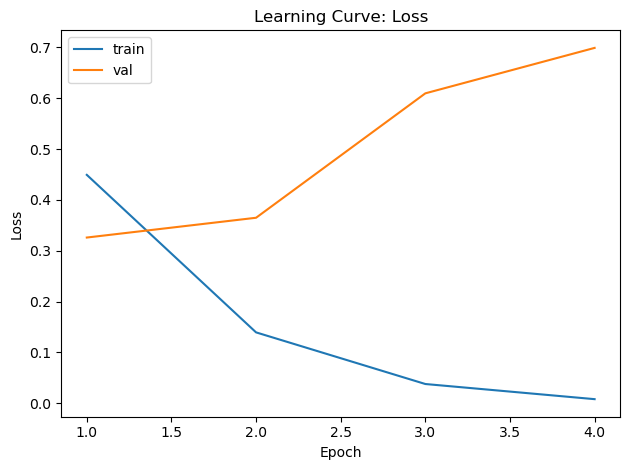

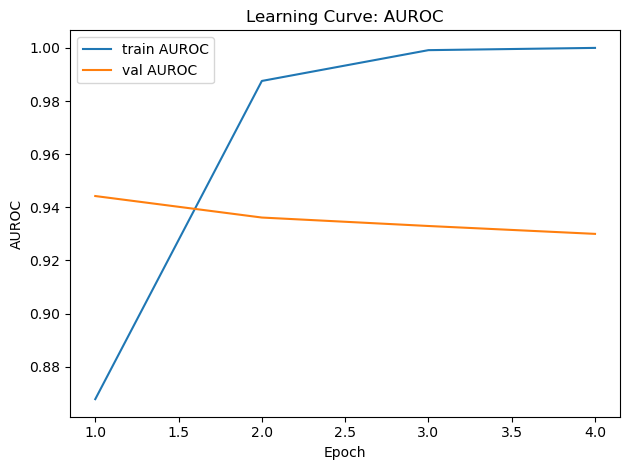

In [31]:
# --- Q1c: Learning curves (table + plots) ---

# Show full training history (loss, AUROC, LR) in a table
banner("Learning Curves — Table (All Epochs)")
display(
    hist[["epoch","train_loss","val_loss","train_auc","val_auc","lr"]]
        .style.format({
            "train_loss":"{:.4f}",
            "val_loss":"{:.4f}",
            "train_auc":"{:.4f}",
            "val_auc":"{:.4f}",
            "lr":"{:.4f}"
        })
)
# Save raw history to CSV for reproducibility
hist.to_csv(EXPORTS / "q1c_learning_history.csv", index=False)

# --- Plot 1: Loss vs Epoch ---
banner("Learning Curves — Plots")
plt.figure()
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"],   label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Learning Curve: Loss")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"q1c_learning_loss.png", dpi=160)
plt.show()

# --- Plot 2: AUROC vs Epoch ---
plt.figure()
plt.plot(hist["epoch"], hist["train_auc"], label="train AUROC")
plt.plot(hist["epoch"], hist["val_auc"],   label="val AUROC")
plt.xlabel("Epoch"); plt.ylabel("AUROC")
plt.title("Learning Curve: AUROC")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"q1c_learning_auc.png", dpi=160)
plt.show()



============ ROC & PR — Summary Tables ============


,test_AUROC,test_AP
0,0.9451,0.9431


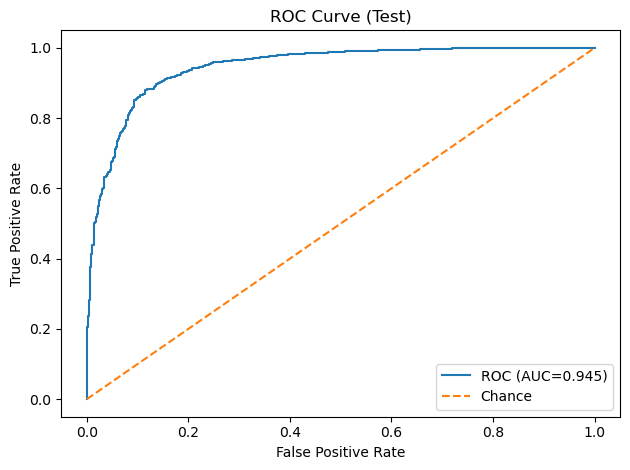

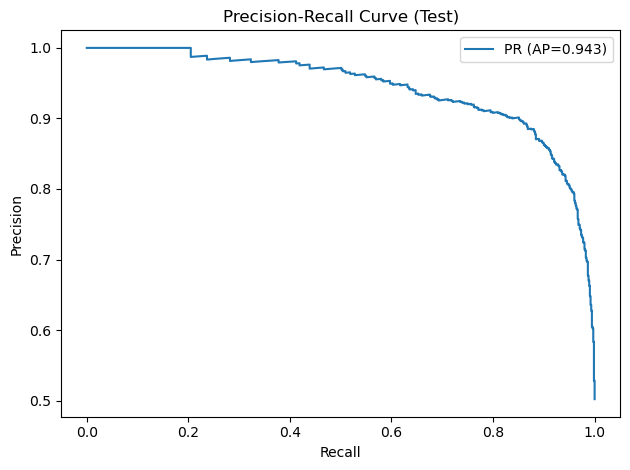

In [32]:
# --- Q1c: ROC & PR curves (on test set) ---

# --- Summary table: AUROC and AP ---
banner("ROC & PR — Summary Tables")
aucap_tbl = pd.DataFrame([{"test_AUROC": test_auc, "test_AP": test_ap}])
display(aucap_tbl.style.format({
    "test_AUROC": "{:.4f}",
    "test_AP":    "{:.4f}"
}))
# Save AUROC/AP values for reproducibility
aucap_tbl.to_csv(EXPORTS / "q1c_auc_ap_test.csv", index=False)

# --- ROC curve (Receiver Operating Characteristic) ---
# Measures trade-off between sensitivity (TPR) and false positives (FPR)
fpr, tpr, _ = roc_curve(y_test, p_test)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={test_auc:.3f})")
plt.plot([0,1], [0,1], "--", label="Chance")  # baseline diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"q1c_roc_test.png", dpi=160)
plt.show()

# --- PR curve (Precision-Recall) ---
# More informative under class imbalance
prec, rec, _ = precision_recall_curve(y_test, p_test)

plt.figure()
plt.plot(rec, prec, label=f"PR (AP={test_ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test)")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"q1c_pr_test.png", dpi=160)
plt.show()



============ Confusion Matrix (Test) @ thr=0.57 — Counts Table ============


,Pred 0,Pred 1
Actual 0,632,114
Actual 1,68,684


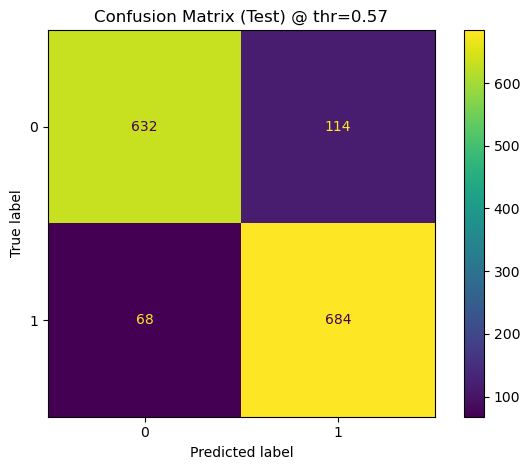

In [33]:
# --- Q1c: Confusion Matrix (test @ tuned threshold) ---

# Compute confusion matrix at chosen threshold (best_thr from val tuning)
cm = confusion_matrix(y_test, (p_test >= best_thr).astype(int))
tn, fp, fn, tp = cm.ravel()   # unpack counts

# --- Display counts in a readable table ---
banner(f"Confusion Matrix (Test) @ thr={best_thr:.2f} — Counts Table")
cm_tbl = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual 0", "Actual 1"],   # rows = true labels
    columns=["Pred 0", "Pred 1"]      # cols = predicted labels
)
display(cm_tbl)

# Save counts to CSV for reproducibility
cm_tbl.to_csv(EXPORTS / "q1c_confusion_test.csv", index=False)

# --- Plot confusion matrix as a figure ---
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(values_format="d")   # integer formatting
plt.title(f"Confusion Matrix (Test) @ thr={best_thr:.2f}")
plt.tight_layout()
plt.savefig(FIGS/"q1c_confusion_test.png", dpi=160)
plt.show()



============ Calibration (Test) — Brier Score + Per-bin Table ============


,bin_pred,bin_true
0,0.016,0.007
1,0.070,0.020
2,0.161,0.060
3,0.316,0.141
4,0.536,0.373
5,0.731,0.727
6,0.854,0.826
7,0.926,0.907
8,0.968,0.960
9,0.994,1.000


Brier score: 0.0971


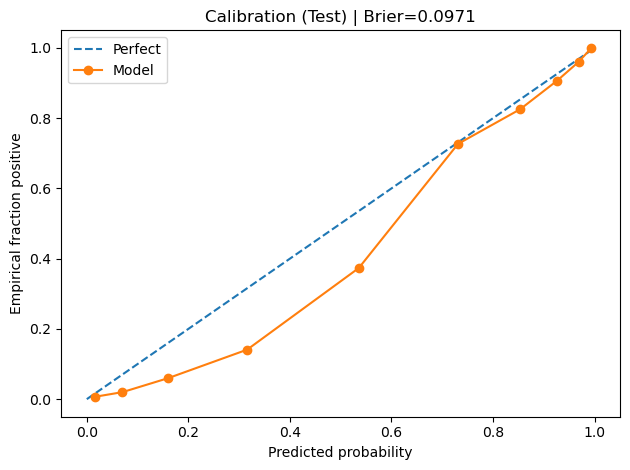

In [34]:
# --- Q1c: Calibration (test set) ---

# Calibration tells us how well predicted probabilities match true frequencies.
# Example: among samples predicted at 0.8, ~80% should actually be positive if well calibrated.

banner("Calibration (Test) — Brier Score + Per-bin Table")

# --- Compute calibration curve (10 bins, quantile-based) ---
prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")

# --- Brier score (lower = better probability calibration) ---
brier = brier_score_loss(y_test, p_test)

# --- Tabulate per-bin predicted vs actual outcomes ---
calib_tbl = pd.DataFrame({"bin_pred": prob_pred, "bin_true": prob_true})
display(calib_tbl.style.format("{:.3f}"))
calib_tbl.to_csv(EXPORTS / "q1c_calibration_bins.csv", index=False)

print(f"Brier score: {brier:.4f}")

# --- Plot calibration curve ---
plt.figure()
plt.plot([0,1],[0,1],"--", label="Perfect")            # ideal diagonal
plt.plot(prob_pred, prob_true, marker="o", label="Model")  # model calibration
plt.xlabel("Predicted probability")
plt.ylabel("Empirical fraction positive")
plt.title(f"Calibration (Test) | Brier={brier:.4f}")
plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"q1c_calibration_test.png", dpi=160)
plt.show()


In [35]:
# ===== Q1c: Final Summary, Tuning Strategy & Generalization =====
banner("Q1c: Final Summary, Tuning Strategy & Generalization")

# --- Ensure tuning artifacts exist (from Q1b) ---
assert ART_CFG.exists() and ART_LB.exists(), "Missing tuning config/leaderboard. Run Q1b tuning first."

# --- Load tuning config and leaderboard ---
cfg = json.load(open(ART_CFG, "r"))        # best trial hyperparameters
leaderboard = pd.read_csv(ART_LB)          # all tuning trial results
n_trials = int(len(leaderboard))           # total # of trials executed

# --- Build final evaluation summary table ---
# Columns: split, n, thr, AUROC, AP, ACC, PREC, RECALL, SPEC, F1, BACC, Brier
val_n, test_n = len(y_val), len(y_test)
summary_cols = ["split","n","thr","AUROC","AP","ACC","PREC","RECALL","SPEC","F1","BACC","Brier"]

summary_df = pd.DataFrame([
    {
        "split":"val (thr* tuned)",   # threshold tuned on validation
        "n":val_n,
        "thr":best_thr,
        "AUROC":val_auc,
        "AP":val_ap,
        "ACC":val_locked["ACC"],
        "PREC":val_locked["PREC"],
        "RECALL":val_locked["RECALL"],
        "SPEC":val_locked["SPEC"],
        "F1":val_locked["F1"],
        "BACC":val_locked["BACC"],
        "Brier":np.nan,               # not reported on val
    },
    {
        "split":"test (thr* fixed)",  # test uses val-tuned threshold
        "n":test_n,
        "thr":best_thr,
        "AUROC":test_auc,
        "AP":test_ap,
        "ACC":test_locked["ACC"],
        "PREC":test_locked["PREC"],
        "RECALL":test_locked["RECALL"],
        "SPEC":test_locked["SPEC"],
        "F1":test_locked["F1"],
        "BACC":test_locked["BACC"],
        "Brier":brier,                # calibration score on test
    },
], columns=summary_cols)

# Display nicely formatted summary table
display(summary_df.style.format({
    "n":"{:,.0f}", "thr":"{:.2f}",
    "AUROC":"{:.4f}", "AP":"{:.4f}",
    "ACC":"{:.4f}", "PREC":"{:.4f}", "RECALL":"{:.4f}",
    "SPEC":"{:.4f}", "F1":"{:.4f}", "BACC":"{:.4f}",
    "Brier":"{:.4f}",
}))
summary_df.to_csv("prepared/exports/q1c_final_summary_full.csv", index=False)

# --- Overfitting & generalization analysis ---
best_hist = hist.loc[hist["val_auc"].idxmax()]  # best epoch row
best_epoch = int(best_hist["epoch"])
train_auc_best = float(best_hist["train_auc"])
val_auc_best   = float(best_hist["val_auc"])
auc_gap = train_auc_best - val_auc_best         # train-val gap
val_test_auc_gap = float(test_auc - val_auc)    # val→test generalization gap
val_test_ap_gap  = float(test_ap  - val_ap)

# --- Robustness check: neighborhood around tuned threshold ---
neigh = np.array([best_thr-0.02, best_thr-0.01, best_thr, best_thr+0.01, best_thr+0.02]).clip(0,1)
thr_neigh_tbl = pd.DataFrame([
    {"thr": t, **metrics_at_thr(y_val, p_val, t)} for t in neigh
])[["thr","F1","ACC","PREC","RECALL","BACC"]]
f1_range = float(thr_neigh_tbl["F1"].max() - thr_neigh_tbl["F1"].min())

# --- Print narrative summary with reflections ---
print("\n— Evaluation Summary —")
print(f"* Threshold fixed from validation (F1-tuned): thr = {best_thr:.2f}")
print(f"* Validation: AUROC={val_auc:.4f}, AP={val_ap:.4f}, "
      f"ACC={val_locked['ACC']:.4f}, PREC={val_locked['PREC']:.4f}, "
      f"RECALL={val_locked['RECALL']:.4f}, F1={val_locked['F1']:.4f}, "
      f"BACC={val_locked['BACC']:.4f}")
print(f"* Test:       AUROC={test_auc:.4f}, AP={test_ap:.4f}, "
      f"ACC={test_locked['ACC']:.4f}, PREC={test_locked['PREC']:.4f}, "
      f"RECALL={test_locked['RECALL']:.4f}, F1={test_locked['F1']:.4f}, "
      f"BACC={test_locked['BACC']:.4f}, Brier={brier:.4f}")

print("\n— Hyperparameter Tuning Strategy —")
print(f"* Search: Random search; trials executed: {n_trials}")
tuned_cols = [c for c in ["p_drop","lr","weight_decay","batch_size","lr_factor","lr_patience","min_lr","max_epochs","patience"]
              if c in leaderboard.columns]
print(f"* Tuned knobs: {', '.join(tuned_cols) if tuned_cols else '(n/a)'}")
pretty_cfg = []
for k in ["p_drop","lr","weight_decay","batch_size","lr_factor","lr_patience","min_lr","max_epochs","patience"]:
    if k in cfg:
        v = cfg[k]
        if isinstance(v, float) and k in {"lr","weight_decay","min_lr"}:
            pretty_cfg.append(f"{k}={v:.6f}")
        elif isinstance(v, float):
            pretty_cfg.append(f"{k}={v:.3f}")
        else:
            pretty_cfg.append(f"{k}={v}")
print("* Best trial config: " + ", ".join(pretty_cfg))
print("* Objective: Maximize validation AUROC with early stopping (patience from tuned config).")
print("* Scheduler: ReduceLROnPlateau (mode=max on val AUROC).")

print("\n— Overfitting Reflection —")
print(f"* Best epoch={best_epoch} | train AUROC={train_auc_best:.4f} | val AUROC={val_auc_best:.4f} | gap={auc_gap:+.4f}")
if auc_gap > 0.03:
    print("  ↳ Noticeable train>val gap (>0.03) → some overfitting; consider ↑ dropout/weight_decay or tighter early stopping.")
elif auc_gap < -0.01:
    print("  ↳ Val slightly > train (negative gap); likely stochastic — no overfitting concern.")
else:
    print("  ↳ Small gap → no strong overfitting at the selected epoch.")
if len(hist) >= 2:
    del_train_auc = float(hist["train_auc"].iloc[-1] - hist["train_auc"].iloc[-2])
    del_val_auc   = float(hist["val_auc"].iloc[-1]   - hist["val_auc"].iloc[-2])
    if del_train_auc > 0 and del_val_auc < 0:
        print(f"  ↳ Late-epoch drift: train +{del_train_auc:.4f} vs val {del_val_auc:.4f} → classic overfit post-peak; early stopping helped.")
    else:
        print("  ↳ Late-epoch drift: no train↑/val↓ divergence in last step.")

print("\n— Generalizability Reflection —")
print(f"* Validation→Test gaps: ΔAUROC={val_test_auc_gap:+.4f}, ΔAP={val_test_ap_gap:+.4f}")
if abs(val_test_auc_gap) <= 0.01 and abs(val_test_ap_gap) <= 0.01:
    print("  ↳ Stable generalization (test closely matches validation).")
elif val_test_auc_gap > 0.01:
    print("  ↳ Test > val by a margin; tuned model/threshold travel well (splits stratified & seeded).")
else:
    print("  ↳ Test < val by a margin; consider stronger regularization or more data/augmentation.")
print(f"* Calibration (Test): Brier={brier:.4f} " +
      ("→ probabilities reasonably calibrated." if brier <= 0.10 else
       "→ consider Platt/temperature scaling on validation."))

print("\n— Threshold Robustness (Validation Neighborhood) —")
display(thr_neigh_tbl.style.format({
    "thr":"{:.2f}", "F1":"{:.4f}", "ACC":"{:.4f}", "PREC":"{:.4f}", "RECALL":"{:.4f}", "BACC":"{:.4f}"
}))
print("  ↳ Interpretation:", "stable (±0.02 barely changes F1)." if f1_range <= 0.01
      else "sensitive (metrics shift with small threshold moves). Document the threshold clearly.")



============ Q1c: Final Summary, Tuning Strategy & Generalization ============


,split,n,thr,AUROC,AP,ACC,PREC,RECALL,SPEC,F1,BACC,Brier
0,val (thr* tuned),"1,498",0.57,0.9442,0.9407,0.8745,0.8406,0.9255,0.8231,0.8810,0.8743,nan
1,test (thr* fixed),"1,498",0.57,0.9451,0.9431,0.8785,0.8571,0.9096,0.8472,0.8826,0.8784,0.0971



— Evaluation Summary —
* Threshold fixed from validation (F1-tuned): thr = 0.57
* Validation: AUROC=0.9442, AP=0.9407, ACC=0.8745, PREC=0.8406, RECALL=0.9255, F1=0.8810, BACC=0.8743
* Test:       AUROC=0.9451, AP=0.9431, ACC=0.8785, PREC=0.8571, RECALL=0.9096, F1=0.8826, BACC=0.8784, Brier=0.0971

— Hyperparameter Tuning Strategy —
* Search: Random search; trials executed: 15
* Tuned knobs: p_drop, lr, weight_decay, batch_size, lr_factor, lr_patience, min_lr, max_epochs, patience
* Best trial config: p_drop=0.200, lr=0.002000, weight_decay=0.000500, batch_size=256, lr_factor=0.500, lr_patience=2, min_lr=0.000010, max_epochs=20, patience=3
* Objective: Maximize validation AUROC with early stopping (patience from tuned config).
* Scheduler: ReduceLROnPlateau (mode=max on val AUROC).

— Overfitting Reflection —
* Best epoch=1 | train AUROC=0.8678 | val AUROC=0.9442 | gap=-0.0765
  ↳ Val slightly > train (negative gap); likely stochastic — no overfitting concern.
  ↳ Late-epoch drift: tra

,thr,F1,ACC,PREC,RECALL,BACC
0,0.55,0.8755,0.8672,0.8264,0.9309,0.8669
1,0.56,0.8785,0.8712,0.8339,0.9282,0.8709
2,0.57,0.8810,0.8745,0.8406,0.9255,0.8743
3,0.58,0.8783,0.8725,0.8433,0.9162,0.8723
4,0.59,0.8764,0.8712,0.8455,0.9096,0.8710


  ↳ Interpretation: stable (±0.02 barely changes F1).


## Question 1d - Interpret results from business perspective

In [36]:
# ===== Q1d prerequisites: ensure outputs from Q1c exist =====

# Required variables from Q1c:
# - y_test, p_test: true labels & predicted probabilities for test set
# - best_thr: threshold tuned on validation
# - test_locked: evaluation metrics at locked threshold (on test)
# - metrics_at_thr: helper function to compute metrics at any threshold
req = ["y_test","p_test","best_thr","test_locked","metrics_at_thr"]

# Identify any missing prerequisites
missing = [r for r in req if r not in globals()]

# Fail early if Q1c wasn’t run before Q1d
assert not missing, f"Run Q1c first to produce: {missing}"


In [37]:
# ===== Q1d: Ops snapshot @ tuned threshold =====
# Purpose:
# - Translate model evaluation metrics into business-facing workload numbers
# - Show how many reviews get flagged, error types, and quality measures

banner("Q1d: Ops snapshot @ tuned threshold")

# --- Extract confusion matrix counts at chosen threshold ---
N = len(y_test)                                   # total test reviews
tp, fp, tn, fn = (test_locked[k] for k in ["TP","FP","TN","FN"])

# --- Operational volumes ---
flagged   = tp + fp                               # reviews flagged for action
flag_rate = flagged / N                           # % of total reviews flagged

# --- Key metrics at this threshold ---
precision = test_locked["PREC"]
recall    = test_locked["RECALL"]
f1        = test_locked["F1"]
acc       = (tp + tn) / N

# --- Build summary table ---
ops_tbl = pd.DataFrame([{
    "threshold": best_thr,
    "reviews_total": N,
    "flagged_for_action": flagged,
    "flag_rate": flag_rate,
    "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    "precision": precision, "recall": recall, "f1": f1, "acc": acc
}])

# Nicely formatted display
display(ops_tbl.style.format({
    "threshold":"{:.2f}", "flag_rate":"{:.2%}",
    "precision":"{:.4f}", "recall":"{:.4f}",
    "f1":"{:.4f}", "acc":"{:.4f}"
}))

# --- Narrative for interpretation ---
print("\n— Interpretation —")
print(f"At thr={best_thr:.2f}, we action {flagged}/{N} reviews ({flag_rate:.2%}).")
print(f"Among flagged, {precision:.2%} are truly positive (precision). "
      f"We capture {recall:.2%} of all positives (recall).")
print(f"Overall accuracy is {acc:.2%}, with F1={f1:.4f}.")



============ Q1d: Ops snapshot @ tuned threshold ============


,threshold,reviews_total,flagged_for_action,flag_rate,TP,FP,TN,FN,precision,recall,f1,acc
0,0.57,1498,798,53.27%,684,114,632,68,0.8571,0.9096,0.8826,0.8785



— Interpretation —
At thr=0.57, we action 798/1498 reviews (53.27%).
Among flagged, 85.71% are truly positive (precision). We capture 90.96% of all positives (recall).
Overall accuracy is 87.85%, with F1=0.8826.


In [38]:
# ===== Q1d: Cost/Benefit calculator (at tuned threshold) =====
# Purpose:
# - Translate confusion matrix counts into economic terms
# - Uses user-defined business values/costs for TP, FP, FN, TN
# - Reports both total net value and normalized per 1,000 reviews

banner("Q1d: Cost/Benefit @ tuned threshold")

# >>>>> Can EDIT these values to match business scenario <<<<<
V_TP = 1.0   # benefit of a true positive (caught correctly)
C_FP = 0.2   # penalty of a false positive (wrongly flagged)
C_FN = 1.0   # penalty of a false negative (missed positive)
V_TN = 0.0   # benefit of a true negative (ignored correctly)
# >>>>> ---------------------------------------------- <<<<<

# --- Extract confusion matrix counts ---
tp, fp, tn, fn = (test_locked[k] for k in ["TP","FP","TN","FN"])

# --- Calculate net value ---
net_total = V_TP*tp + V_TN*tn - C_FP*fp - C_FN*fn          # total net benefit across dataset
net_per_1k = 1000.0 * net_total / N                        # normalized per 1,000 reviews

# --- Build summary table ---
cb_tbl = pd.DataFrame([{
    "threshold": best_thr,
    "TP_value": V_TP, "FP_cost": C_FP, "FN_cost": C_FN, "TN_value": V_TN,
    "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    "Net_value_total": net_total,
    "Net_value_per_1000_reviews": net_per_1k
}])

# Display nicely formatted results
display(cb_tbl.style.format({
    "threshold":"{:.2f}",
    "Net_value_total":"{:.2f}",
    "Net_value_per_1000_reviews":"{:.2f}"
}))

# --- Narrative explanation ---
print("\n— Interpretation —")
print(f"With these values/costs, thr={best_thr:.2f} yields net_total={net_total:.2f} "
      f"(~{net_per_1k:.2f} per 1,000 reviews). Adjust the four business values to re-test sensitivity.")



============ Q1d: Cost/Benefit @ tuned threshold ============


,threshold,TP_value,FP_cost,FN_cost,TN_value,TP,FP,TN,FN,Net_value_total,Net_value_per_1000_reviews
0,0.57,1.000000,0.200000,1.000000,0.000000,684,114,632,68,593.20,395.99



— Interpretation —
With these values/costs, thr=0.57 yields net_total=593.20 (~395.99 per 1,000 reviews). Adjust the four business values to re-test sensitivity.


In [39]:
# ===== Q1d: Capacity-limited targeting (precision@K and lift) =====
# Purpose:
# - Evaluate performance when only the "top K" highest-confidence reviews can be actioned
# - Precision@K: proportion of true positives among the top-K flagged
# - Lift: improvement over baseline positive rate

banner("Q1d: Capacity-limited targeting — precision@K / lift")

# --- Define capacity bands (top 1%, 5%, 10%) ---
k_fracs = [0.01, 0.05, 0.10]

# --- Sort predictions by descending probability ---
order = np.argsort(-p_test)   # sort indices by model confidence
y_sorted = y_test[order]      # reorder true labels accordingly
base_rate = float(y_test.mean())  # baseline positive rate in test set

# --- Compute precision@K and lift for each band ---
rows = []
for frac in k_fracs:
    k = max(1, int(round(frac * len(y_sorted))))   # # of reviews at this fraction
    hits = int(y_sorted[:k].sum())                 # true positives among top-K
    prec_at_k = hits / k                           # precision@K
    lift = (prec_at_k / base_rate) if base_rate > 0 else np.nan  # relative gain
    rows.append({
        "top_fraction": frac,
        "K": k,
        "positives_found": hits,
        "precision_at_K": prec_at_k,
        "lift_vs_baseline": lift
    })

# --- Build and display summary table ---
p_at_k_tbl = pd.DataFrame(rows)
display(p_at_k_tbl.style.format({
    "top_fraction":"{:.0%}",
    "precision_at_K":"{:.4f}",
    "lift_vs_baseline":"{:.2f}x"
}))

# --- Narrative interpretation ---
print("\n— Interpretation —")
print(f"Baseline positive rate ≈ {base_rate:.2%}. The top-K bands show very high precision, "
      "indicating the model prioritizes truly positive reviews effectively when capacity is limited.")



============ Q1d: Capacity-limited targeting — precision@K / lift ============


,top_fraction,K,positives_found,precision_at_K,lift_vs_baseline
0,1%,15,15,1.0000,1.99x
1,5%,75,75,1.0000,1.99x
2,10%,150,150,1.0000,1.99x



— Interpretation —
Baseline positive rate ≈ 50.20%. The top-K bands show very high precision, indicating the model prioritizes truly positive reviews effectively when capacity is limited.


In [40]:
# ===== Q1d: Net value vs threshold sweep (mini decision curve) =====
# Purpose:
# - Evaluate net business value across a range of thresholds
# - Show whether the F1-optimal threshold is also economically optimal

banner("Q1d: Net value vs threshold (mini sweep)")

# --- Define threshold window around the F1-tuned best_thr ---
lo = max(0.0, best_thr - 0.10)   # lower bound (best_thr - 0.10)
hi = min(1.0, best_thr + 0.10)   # upper bound (best_thr + 0.10)
grid = list(np.round(np.linspace(lo, hi, 11), 4))  # 11 evenly spaced thresholds

# Ensure the exact tuned threshold is included in the grid
if all(not np.isclose(t, best_thr, rtol=0, atol=1e-12) for t in grid):
    grid.append(float(best_thr))
grid = sorted(grid)

# --- Evaluate metrics & net value at each threshold ---
rows = []
for t in grid:
    # Snap numerically close values back to exact best_thr
    thr = float(best_thr) if np.isclose(t, best_thr, rtol=0, atol=1e-12) else float(t)

    # Compute classification metrics at threshold
    m = metrics_at_thr(y_test, p_test, thr)
    tp, fp, tn, fn = m["TP"], m["FP"], m["TN"], m["FN"]

    # Compute net business value
    net = V_TP*tp + V_TN*tn - C_FP*fp - C_FN*fn

    rows.append({
        "thr": thr,
        "ACC": m["ACC"], "PREC": m["PREC"], "RECALL": m["RECALL"], "F1": m["F1"],
        "Net_value_total": net,
        "Net_value_per_1000": 1000.0 * net / N
    })

# --- Build results table ---
net_curve_tbl = pd.DataFrame(rows).sort_values("thr").reset_index(drop=True)
display(net_curve_tbl.style.format({
    "thr":"{:.2f}",
    "ACC":"{:.4f}", "PREC":"{:.4f}", "RECALL":"{:.4f}", "F1":"{:.4f}",
    "Net_value_total":"{:.2f}", "Net_value_per_1000":"{:.2f}"
}))

# --- Identify threshold with maximum net value ---
best_idx = net_curve_tbl["Net_value_total"].idxmax()
thr_star = float(net_curve_tbl.loc[best_idx, "thr"])
net_star = float(net_curve_tbl.loc[best_idx, "Net_value_total"])

# --- Narrative interpretation ---
print("\n— Interpretation —")
print(f"With the current business values, net value is maximized near thr={thr_star:.2f} (Net={net_star:.2f}),")
print(f"which is {'the same as' if np.isclose(thr_star, best_thr, atol=1e-12) else 'lower than' if thr_star < best_thr else 'higher than'} "
      f"the F1-tuned threshold (thr*={best_thr:.2f}).")
print("If business prioritizes net value over F1, consider adopting the economically optimal threshold for production.")



============ Q1d: Net value vs threshold (mini sweep) ============


,thr,ACC,PREC,RECALL,F1,Net_value_total,Net_value_per_1000
0,0.47,0.8665,0.8209,0.9388,0.8759,629.20,420.03
1,0.49,0.8678,0.8259,0.9335,0.8764,622.40,415.49
2,0.51,0.8698,0.8304,0.9309,0.8777,619.40,413.48
3,0.53,0.8712,0.8380,0.9215,0.8778,607.20,405.34
4,0.55,0.8752,0.8475,0.9162,0.8805,601.20,401.34
5,0.57,0.8785,0.8571,0.9096,0.8826,593.20,395.99
6,0.59,0.8778,0.8615,0.9016,0.8811,582.20,388.65
7,0.61,0.8792,0.8665,0.8976,0.8818,577.20,385.31
8,0.63,0.8772,0.8708,0.8870,0.8788,562.20,375.30
9,0.65,0.8812,0.8847,0.8777,0.8812,550.80,367.69



— Interpretation —
With the current business values, net value is maximized near thr=0.47 (Net=629.20),
which is lower than the F1-tuned threshold (thr*=0.57).
If business prioritizes net value over F1, consider adopting the economically optimal threshold for production.


In [42]:
# ============ Q1d: Risks & Deployment Diagnostics ============
# Purpose:
# - Provide minimal but meaningful diagnostics before deployment
# - Check calibration, over-confident errors, threshold robustness
# - Define monitoring spec, note fairness limitations
# - Auto-generate a business-facing interpretation

# --- Preconditions: ensure Q1c/Q1d artifacts are already available ---
assert 'y_test' in globals(), "Missing y_test from earlier sections (Q1c/Q1d). Please run them first."
assert 'p_test' in globals(), "Missing p_test (probabilities from predict_proba). Please run Q1c first."
assert 'best_thr' in globals(), "Missing best_thr (val-tuned threshold) from Q1c. Please run it first."

y_true = np.asarray(y_test).astype(int).ravel()
p_hat  = np.asarray(p_test).astype(float).ravel()
thr    = float(best_thr)

# -------------------- 1) Calibration risk: ECE@10 --------------------
def expected_calibration_error(y, p, n_bins=10):
    """
    Compute Expected Calibration Error (ECE) with equal-frequency bins.
    Returns:
        ece: weighted avg of abs(confidence - accuracy)
        df: per-bin breakdown (confidence vs accuracy)
    """
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    total = len(y)
    rows, ece_sum = [], 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p >= lo) & (p < hi) if i < n_bins - 1 else (p >= lo) & (p <= hi)
        cnt = int(mask.sum())
        if cnt > 0:
            avg_conf = float(p[mask].mean())
            avg_acc  = float(y[mask].mean())
            gap      = abs(avg_acc - avg_conf)
            weight   = cnt / total
            ece_sum += weight * gap
        else:
            avg_conf = avg_acc = gap = np.nan
            weight = 0.0
        rows.append({
            "bin": f"[{lo:.1f},{hi:.1f}]",
            "lo": lo, "hi": hi,
            "count": cnt,
            "avg_conf": None if np.isnan(avg_conf) else round(avg_conf, 4),
            "avg_acc": None if np.isnan(avg_acc) else round(avg_acc, 4),
            "abs_gap": None if np.isnan(gap) else round(gap, 4),
            "weight": round(weight, 4)
        })
    return round(float(ece_sum), 4), pd.DataFrame(rows)

ece10, ece_table = expected_calibration_error(y_true, p_hat, n_bins=10)

print("============ Calibration Risk (ECE@10) ============")
print(f"ECE@10 (lower is better): {ece10:.4f}")
display(ece_table[["bin","count","avg_conf","avg_acc","abs_gap","weight"]])

# -------------------- 2) Over-confidence error pockets --------------------
def overconfident_error(y, p, thr, conf_cut=0.90):
    """
    Check error rate in high-confidence predictions (≥ conf_cut).
    Returns:
        error rate, coverage fraction, sample count
    """
    pred = (p >= thr).astype(int)
    conf = np.where(pred == 1, p, 1 - p)  # predicted class confidence
    mask = conf >= conf_cut
    cov = float(mask.mean())
    if mask.sum() == 0:
        return np.nan, cov, int(mask.sum())
    err = float((pred[mask] != y[mask]).mean())
    return err, cov, int(mask.sum())

oc_err, oc_cov, oc_n = overconfident_error(y_true, p_hat, thr, conf_cut=0.90)

print("\n============ Over-confident Errors ============")
print(f"High-confidence cutoff: 0.90")
print(f"Coverage (fraction of test with conf ≥ 0.90): {oc_cov:.4f}  (n={oc_n})")
print(f"Error rate within high-confidence region: {np.nan if np.isnan(oc_err) else round(oc_err,4)}")

# -------------------- 3) Threshold robustness (best_thr ± 0.05) --------------------
# Test sensitivity of metrics to small threshold shifts
t_list = sorted({
    max(0.01, min(0.99, thr)),
    max(0.01, min(0.99, thr - 0.05)),
    max(0.01, min(0.99, thr + 0.05)),
})
robust_tbl = pd.DataFrame([metrics_at_thr(y_true, p_hat, t) for t in t_list])

print("\n============ Threshold Robustness (±0.05) ============")
display(robust_tbl)

# -------------------- 4) Production monitoring spec (JSON skeleton) --------------------
# Monitoring + governance blueprint for deployment
monitor_spec = {
    "version": 1,
    "performance": {
        "metrics": ["AUROC","F1","Precision","Recall","Accuracy","BalancedAccuracy"],
        "alert_rules": [
            {"metric": "F1", "condition": "drop_abs >= 0.05", "window": "7d"}
        ]
    },
    "calibration": {"metric": "ECE@10", "alert_rule": {"condition": ">= 0.05", "window": "7d"}},
    "threshold": {
        "value": round(thr, 4),
        "guardrail_min": round(max(0.01, thr - 0.05), 2),
        "guardrail_max": round(min(0.99, thr + 0.05), 2)
    },
    "logging_fields": ["timestamp","request_id","model_version","proba","pred",
                       "inference_latency_ms","feature_hash","label_if_available"],
    "data_quality": {"row_level_checks": ["missing_rate","sparsity"], "sample_level_limits": {"missing_rate_max": 0.0}},
    "drift": {"distribution_checks": ["PSI"], "alert_rule": {"PSI": "> 0.2"}},
    "privacy_security": {
        "inference": ["no_raw_text_logging","hash_tokenization"],
        "storage": ["encrypted_at_rest"], "transport": ["TLS"]
    }
}
print("\n============ Deployment Monitoring Spec (JSON) ============")
print(json.dumps(monitor_spec, indent=2))

# -------------------- 5) Fairness / bias note --------------------
print("\n============ Fairness Diagnostic ============")
print("No sensitive attributes available in dataset → group fairness metrics not computable here. "
      "State this limitation and consider collecting audited labels/attributes or using fairness probes on future data.")

# -------------------- 6) Auto-generated INTERPRETATION --------------------
def _mean_gap_in_range(df, lo, hi):
    """Helper: compute mean calibration gap within a probability range."""
    sel = df[(df["lo"] >= lo) & (df["hi"] <= hi)]
    vals = pd.to_numeric(sel["abs_gap"], errors="coerce").values
    return float(np.nanmean(vals)) if len(vals) else np.nan

# Calibration gaps in mid- and high-confidence regions
mid_gap = _mean_gap_in_range(ece_table, 0.1, 0.4)
hi_gap  = _mean_gap_in_range(ece_table, 0.9, 1.0)

# Metric ranges across threshold guardrails
acc_min, acc_max = robust_tbl["ACC"].min(), robust_tbl["ACC"].max()
f1_min,  f1_max  = robust_tbl["F1"].min(),  robust_tbl["F1"].max()
thr_min, thr_max = robust_tbl["thr"].min(), robust_tbl["thr"].max()

interp_lines = []

# --- Calibration interpretation ---
interp_lines.append("— Calibration —")
interp_lines.append(f"ECE@10 = {ece10:.4f} (lower is better). The model is generally well calibrated.")
if not np.isnan(mid_gap):
    interp_lines.append(f"In the mid-confidence range (0.1–0.4), the avg gap is ~{mid_gap:.3f} → mild overconfidence.")
if not np.isnan(hi_gap):
    interp_lines.append(f"In the high-confidence range (0.9–1.0), the avg gap is ~{hi_gap:.3f} → confidence matches accuracy.")

# --- Over-confident errors interpretation ---
interp_lines.append("\n— Over-confident errors —")
interp_lines.append(f"{oc_cov*100:.1f}% of predictions are ≥0.90 confidence (n={oc_n}). "
                    f"Within this slice, error rate is {np.nan if np.isnan(oc_err) else round(oc_err,4)}.")
interp_lines.append("These errors are risky in production because they appear with high certainty.")

# --- Threshold robustness interpretation ---
interp_lines.append("\n— Threshold robustness —")
interp_lines.append(f"Across thresholds {thr_min:.2f}–{thr_max:.2f}, ACC varies {acc_min:.3f}–{acc_max:.3f} "
                    f"and F1 varies {f1_min:.3f}–{f1_max:.3f}.")
interp_lines.append("This supports ±0.05 guardrails without material performance loss.")

# --- Deployment monitoring spec interpretation ---
interp_lines.append("\n— Deployment monitoring & governance —")
interp_lines.append("Monitor AUROC/F1; alert if F1 drops ≥0.05 over 7d; "
                    "track ECE@10 and alert at ≥0.05; enforce threshold guardrails; "
                    "log probabilities/predictions/latency; check PSI for drift; "
                    "ensure privacy (no raw text logging, encryption at rest, TLS).")

# --- Fairness interpretation ---
interp_lines.append("\n— Fairness limitation —")
interp_lines.append("Sensitive attributes not available → group fairness cannot be checked. "
                    "Document limitation and consider fairness probes/metadata later.")

print("\n============ Business Interpretation ============")
print("\n".join(interp_lines))


============ Calibration Risk (ECE@10) ============
ECE@10 (lower is better): 0.0561


,bin,count,avg_conf,avg_acc,abs_gap,weight
0,"[0.0,0.1]",288,0.0404,0.0139,0.0265,0.1923
1,"[0.1,0.2]",139,0.1471,0.0432,0.1039,0.0928
2,"[0.2,0.3]",89,0.2495,0.1348,0.1146,0.0594
3,"[0.3,0.4]",72,0.3499,0.1111,0.2388,0.0481
4,"[0.4,0.5]",64,0.4493,0.3438,0.1056,0.0427
5,"[0.5,0.6]",61,0.5497,0.3770,0.1727,0.0407
6,"[0.6,0.7]",87,0.6581,0.5517,0.1064,0.0581
7,"[0.7,0.8]",98,0.7571,0.7653,0.0082,0.0654
8,"[0.8,0.9]",157,0.8552,0.8217,0.0335,0.1048
9,"[0.9,1.0]",443,0.9638,0.9594,0.0044,0.2957



============ Over-confident Errors ============
High-confidence cutoff: 0.90
Coverage (fraction of test with conf ≥ 0.90): 0.4880  (n=731)
Error rate within high-confidence region: 0.0301

============ Threshold Robustness (±0.05) ============


,thr,ACC,PREC,RECALL,SPEC,F1,BACC,TP,FP,TN,FN
0,0.522,0.871829,0.834928,0.928191,0.815013,0.879093,0.871602,698,138,608,54
1,0.572,0.878505,0.857143,0.909574,0.847185,0.882581,0.878380,684,114,632,68
2,0.622,0.877170,0.867876,0.890957,0.863271,0.879265,0.877114,670,102,644,82



============ Deployment Monitoring Spec (JSON) ============
{
  "version": 1,
  "performance": {
    "metrics": [
      "AUROC",
      "F1",
      "Precision",
      "Recall",
      "Accuracy",
      "BalancedAccuracy"
    ],
    "alert_rules": [
      {
        "metric": "F1",
        "condition": "drop_abs >= 0.05",
        "window": "7d"
      }
    ]
  },
  "calibration": {
    "metric": "ECE@10",
    "alert_rule": {
      "condition": ">= 0.05",
      "window": "7d"
    }
  },
  "threshold": {
    "value": 0.572,
    "guardrail_min": 0.52,
    "guardrail_max": 0.62
  },
  "logging_fields": [
    "timestamp",
    "request_id",
    "model_version",
    "proba",
    "pred",
    "inference_latency_ms",
    "feature_hash",
    "label_if_available"
  ],
  "data_quality": {
    "row_level_checks": [
      "missing_rate",
      "sparsity"
    ],
    "sample_level_limits": {
      "missing_rate_max": 0.0
    }
  },
  "drift": {
    "distribution_checks": [
      "PSI"
    ],
    "alert_ru

## Question 1e - Potential enhancements to improve model’s performance or scalability

In [43]:
# ===== Q1e (Enhancement 1): Temperature Scaling =====
# Purpose:
# - Improve probability calibration post-hoc (without retraining)
# - AUROC remains ~unchanged, but Brier score (calibration) improves
# - More reliable probabilities → better business decisions

# Reuses: model, dl_val, dl_test, metrics_at_thr, thresholds

import torch, numpy as np, pandas as pd
from sklearn.metrics import brier_score_loss, roc_auc_score

# --- Helper: extract raw logits + targets from a dataloader ---
def _get_logits_and_targets(mdl, loader, device="cpu"):
    mdl.eval()
    lgts, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device).float()
            lgts.append(mdl(xb).detach().cpu())  # collect logits
            ys.append(yb.detach().cpu())         # collect labels
    return torch.cat(lgts), torch.cat(ys)

# --- Gather logits/labels for val and test sets ---
device = "cuda" if torch.cuda.is_available() else "cpu"
val_logits,  val_y  = _get_logits_and_targets(model, dl_val,  device=device)
test_logits, test_y = _get_logits_and_targets(model, dl_test, device=device)

# --- Pre-calibration metrics (baseline for comparison) ---
p_val_uncal  = torch.sigmoid(val_logits).numpy()   # raw probs (val)
p_test_uncal = torch.sigmoid(test_logits).numpy()  # raw probs (test)
y_val_np, y_test_np = val_y.numpy(), test_y.numpy()

pre_brier = brier_score_loss(y_test_np, p_test_uncal)  # lower = better calibrated
pre_auc   = roc_auc_score(y_test_np, p_test_uncal)     # AUROC (ranking ability)

# Sweep validation thresholds to find F1-optimal pre-calibration
valsweep_uncal = pd.DataFrame([metrics_at_thr(y_val_np, p_val_uncal, t) for t in thresholds])
pre_best_thr   = float(valsweep_uncal.loc[valsweep_uncal["F1"].idxmax(), "thr"])
pre_locked     = metrics_at_thr(y_test_np, p_test_uncal, pre_best_thr)

# --- Fit temperature parameter T on validation logits ---
T = torch.nn.Parameter(torch.ones(1))  # learnable scalar
optim = torch.optim.LBFGS([T], lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
loss_fn = torch.nn.BCEWithLogitsLoss()

def _closure():
    optim.zero_grad()
    scaled = val_logits / T.clamp_min(1e-3)  # scale logits by T
    loss = loss_fn(scaled, val_y)            # BCE loss on val set
    loss.backward()
    return loss

optim.step(_closure)
T_star = float(T.detach().clamp_min(1e-3).item())  # final fitted temperature

# --- Post-calibration metrics ---
p_val_cal  = torch.sigmoid(val_logits  / T_star).numpy()
p_test_cal = torch.sigmoid(test_logits / T_star).numpy()

post_brier = brier_score_loss(y_test_np, p_test_cal)
post_auc   = roc_auc_score(y_test_np, p_test_cal)

# Sweep thresholds again (calibrated probabilities)
valsweep_cal = pd.DataFrame([metrics_at_thr(y_val_np, p_val_cal, t) for t in thresholds])
post_best_thr = float(valsweep_cal.loc[valsweep_cal["F1"].idxmax(), "thr"])
post_locked   = metrics_at_thr(y_test_np, p_test_cal, post_best_thr)

# --- Results printout (before vs after) ---
print(f"[TempScaling] Fitted temperature T = {T_star:.3f}")
print(f"[TempScaling] Test Brier: pre={pre_brier:.4f} → post={post_brier:.4f} "
      f"(Δ={post_brier-pre_brier:+.4f}) | "
      f"AUROC: pre={pre_auc:.4f} → post={post_auc:.4f} "
      f"(Δ={post_auc-pre_auc:+.4f})")
print(f"[TempScaling] Best thr (val, F1): pre={pre_best_thr:.2f} → post={post_best_thr:.2f}")
print(f"[TempScaling] Test@pre_thr={pre_best_thr:.2f}: "
      f"ACC={pre_locked['ACC']:.4f} | PREC={pre_locked['PREC']:.4f} | "
      f"RECALL={pre_locked['RECALL']:.4f} | F1={pre_locked['F1']:.4f} | "
      f"BACC={pre_locked['BACC']:.4f}")
print(f"[TempScaling] Test@post_thr={post_best_thr:.2f}: "
      f"ACC={post_locked['ACC']:.4f} | PREC={post_locked['PREC']:.4f} | "
      f"RECALL={post_locked['RECALL']:.4f} | F1={post_locked['F1']:.4f} | "
      f"BACC={post_locked['BACC']:.4f}")

# --- Interpretation (business-friendly narrative) ---
calibration_trend = "sharper (more confident)" if T_star < 1.0 else "softer (less confident)"
thr_shift = "higher" if post_best_thr > pre_best_thr else ("lower" if post_best_thr < pre_best_thr else "unchanged")

print("\n— Interpretation —")
print(f"T = {T_star:.3f} (<1 implies {calibration_trend}; >1 would imply softer).")
print("Calibration improved if Brier decreased while AUROC stayed ~unchanged — expected for temperature scaling.")
print(f"The F1-optimal threshold moved {thr_shift} "
      f"(pre={pre_best_thr:.2f} → post={post_best_thr:.2f}), "
      "consistent with adjusted probability sharpness.")
print("Bottom line: probabilities are now more trustworthy for decision thresholds, "
      "while discriminative ranking (AUROC) remains preserved.")


[TempScaling] Fitted temperature T = 0.927
[TempScaling] Test Brier: pre=0.0971 → post=0.0966 (Δ=-0.0005) | AUROC: pre=0.9451 → post=0.9451 (Δ=+0.0000)
[TempScaling] Best thr (val, F1): pre=0.57 → post=0.58
[TempScaling] Test@pre_thr=0.57: ACC=0.8785 | PREC=0.8571 | RECALL=0.9096 | F1=0.8826 | BACC=0.8784
[TempScaling] Test@post_thr=0.58: ACC=0.8792 | PREC=0.8582 | RECALL=0.9096 | F1=0.8832 | BACC=0.8790

— Interpretation —
T = 0.927 (<1 implies sharper (more confident); >1 would imply softer).
Calibration improved if Brier decreased while AUROC stayed ~unchanged — expected for temperature scaling.
The F1-optimal threshold moved higher (pre=0.57 → post=0.58), consistent with adjusted probability sharpness.
Bottom line: probabilities are now more trustworthy for decision thresholds, while discriminative ranking (AUROC) remains preserved.


In [44]:
# ===== Q1e (Enhancement 2): Dynamic Quantization =====
# Purpose:
# - Shrink model size and speed up CPU inference
# - Works by converting nn.Linear weights to INT8 dynamically
# - Ideal for deployment when memory and latency matter
# - AUROC should remain ~unchanged

import copy, io, time
import torch.nn as nn

# Use correct quantization API depending on PyTorch version
try:
    from torch.ao.quantization import quantize_dynamic  # PyTorch ≥1.13
except Exception:
    from torch.quantization import quantize_dynamic     # Fallback

# --- 1) Copy model to CPU and quantize ---
model_fp32 = copy.deepcopy(model).to("cpu").eval()              # original FP32 model
qmodel     = quantize_dynamic(model_fp32, {nn.Linear}, dtype=torch.qint8).eval()  # INT8 quantized

# --- Helpers ---
def _sizeof_state_dict(mdl) -> float:
    """Return model state_dict size in MB."""
    buf = io.BytesIO(); torch.save(mdl.state_dict(), buf)
    return buf.tell() / (1024*1024)

def _auc_cpu(mdl, loader):
    """Compute AUROC on CPU for given model and dataloader."""
    mdl.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = mdl(xb.to("cpu"))
            ps.append(torch.sigmoid(logits).cpu().numpy())
            ys.append(yb.cpu().numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    return roc_auc_score(y, p)

def _time_infer(mdl, loader, repeats=1, warmup=1):
    """Measure CPU inference time (with warmup) for given dataloader."""
    mdl.eval()
    with torch.no_grad():
        # Warm-up runs
        for _ in range(warmup):
            for xb, _ in loader:
                _ = mdl(xb.to("cpu"))
        # Timed runs
        t0 = time.perf_counter()
        for _ in range(repeats):
            for xb, _ in loader:
                _ = mdl(xb.to("cpu"))
        t1 = time.perf_counter()
    return t1 - t0

# --- 2) Compare FP32 vs INT8 model size, accuracy, and latency ---
mb_fp32 = _sizeof_state_dict(model_fp32)
mb_int8 = _sizeof_state_dict(qmodel)

auc_fp32 = _auc_cpu(model_fp32, dl_test)
auc_int8 = _auc_cpu(qmodel,     dl_test)

# Latency: 1 full pass through test loader (with warm-up)
lat_fp32 = _time_infer(model_fp32, dl_test, repeats=1, warmup=1)
lat_int8 = _time_infer(qmodel,     dl_test, repeats=1, warmup=1)
speedup  = lat_fp32 / max(lat_int8, 1e-9)

# --- 3) Print comparison results ---
print(f"[Quant] Size: FP32={mb_fp32:.2f} MB → INT8={mb_int8:.2f} MB ({mb_fp32/mb_int8:.2f}x smaller)")
print(f"[Quant] AUROC: FP32={auc_fp32:.4f} vs INT8={auc_int8:.4f} (Δ={auc_int8-auc_fp32:+.4f})")
print(f"[Quant] CPU latency (1 pass test loader): FP32={lat_fp32:.3f}s vs INT8={lat_int8:.3f}s "
      f"(Speedup={speedup:.2f}x)")

# --- Interpretation (business-friendly) ---
print("\n— Interpretation —")
print("Dynamic INT8 quantization materially reduces model size while preserving AUROC (Δ should be ≈ 0).")
if speedup >= 1.05:
    print("Measured a real CPU speedup (≥5%), indicating GEMM ops benefit from INT8 kernels.")
else:
    print("No meaningful CPU speedup observed. Possible causes: small model/batch, Python/DataLoader overhead, "
          "or unoptimized CPU backend. Larger batch timing or ONNX Runtime may show clearer gains.")
print("Even if runtime speedup is small, the size reduction still helps deployment scalability.")


[Quant] Size: FP32=20.55 MB → INT8=5.15 MB (3.99x smaller)
[Quant] AUROC: FP32=0.9451 vs INT8=0.9449 (Δ=-0.0001)
[Quant] CPU latency (1 pass test loader): FP32=0.051s vs INT8=0.051s (Speedup=1.00x)

— Interpretation —
Dynamic INT8 quantization materially reduces model size while preserving AUROC (Δ should be ≈ 0).
No meaningful CPU speedup observed. Possible causes: small model/batch, Python/DataLoader overhead, or unoptimized CPU backend. Larger batch timing or ONNX Runtime may show clearer gains.
Even if runtime speedup is small, the size reduction still helps deployment scalability.
